In [126]:
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import warnings
import pandas as pd
import numpy as np
import time
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import CalibrationDisplay
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import mlflow
import shap
import optuna
from optuna.integration.mlflow import MLflowCallback
import joblib
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
from azureml.core import Workspace
import logging
import warnings
import os
import shutil


warnings.filterwarnings("ignore")
logging.getLogger("azure").setLevel(logging.ERROR)
logging.getLogger("azure.ai.ml").setLevel(logging.ERROR)
logging.getLogger("mlflow").setLevel(logging.ERROR)
logging.getLogger("opentelemetry").setLevel(logging.ERROR)

In [2]:
ml_client = MLClient.from_config(credential=DefaultAzureCredential())
data_asset = ml_client.data.get(name='clinvar_enriched', version='1.0.0')
df_enriched = pd.read_parquet(data_asset.path)

In [3]:
df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CLNSIG                                 20000 non-null  float64
 1   CHROM                                  20000 non-null  object 
 2   POS                                    20000 non-null  object 
 3   REF                                    20000 non-null  object 
 4   ALT                                    20000 non-null  object 
 5   MC                                     19881 non-null  object 
 6   GENEINFO                               19998 non-null  object 
 7   CLNVC                                  20000 non-null  object 
 8   AF_EXAC                                3631 non-null   object 
 9   AF_TGP                                 2280 non-null   object 
 10  AF_ESP                                 1720 non-null   object 
 11  OR

In [4]:
df_enriched.head()

,CLNSIG,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,AF_EXAC,AF_TGP,...,ORIGIN,CLNREVSTAT,CLNDN,gnomad_exome.af.af,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,dbnsfp.interpro.domain,GENE_SYMBOL,GENE_pLI,GENE_LOEUF
0,0.0,16,82098197,T,C,SO:0001819|synonymous_variant,HSD17B2:3294,single_nucleotide_variant,0.00040,0.00240,...,1,"criteria_provided,_single_submitter",not_provided,0.000319,NaN,NaN,None,HSD17B2,NaN,NaN
1,0.0,18,23552607,G,C,SO:0001627|intron_variant,NPC1:4864,single_nucleotide_variant,None,0.83107,...,1,"criteria_provided,_single_submitter",not_provided,NaN,NaN,NaN,None,NPC1,NaN,NaN
2,0.0,1,16996311,A,G,SO:0001627|intron_variant,ATP13A2:23400,single_nucleotide_variant,None,None,...,1,"criteria_provided,_single_submitter",Autosomal_recessive_spastic_paraplegia_type_78...,NaN,NaN,NaN,None,ATP13A2,NaN,NaN
3,0.0,16,89280475,C,G,SO:0001583|missense_variant,ANKRD11:29123,single_nucleotide_variant,None,0.03754,...,1,"criteria_provided,_multiple_submitters,_no_con...",not_provided|KBG_syndrome|Inborn_genetic_disea...,0.045592,0.467,0.009,None,ANKRD11,NaN,NaN
4,0.0,18,55279612,C,T,"SO:0001623|5_prime_UTR_variant,SO:0001819|syno...",TCF4:6925,single_nucleotide_variant,0.00005,None,...,1,"criteria_provided,_multiple_submitters,_no_con...",Pitt-Hopkins_syndrome|not_specified|not_provided,0.000044,NaN,NaN,None,TCF4,NaN,NaN


In [5]:
df_enriched = df_enriched.drop(columns=['GENE_pLI', 'GENE_LOEUF'], axis=1)

In [6]:
df_enriched.head()

,CLNSIG,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,AF_EXAC,AF_TGP,AF_ESP,ORIGIN,CLNREVSTAT,CLNDN,gnomad_exome.af.af,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,dbnsfp.interpro.domain,GENE_SYMBOL
0,0.0,16,82098197,T,C,SO:0001819|synonymous_variant,HSD17B2:3294,single_nucleotide_variant,0.00040,0.00240,None,1,"criteria_provided,_single_submitter",not_provided,0.000319,NaN,NaN,None,HSD17B2
1,0.0,18,23552607,G,C,SO:0001627|intron_variant,NPC1:4864,single_nucleotide_variant,None,0.83107,None,1,"criteria_provided,_single_submitter",not_provided,NaN,NaN,NaN,None,NPC1
2,0.0,1,16996311,A,G,SO:0001627|intron_variant,ATP13A2:23400,single_nucleotide_variant,None,None,None,1,"criteria_provided,_single_submitter",Autosomal_recessive_spastic_paraplegia_type_78...,NaN,NaN,NaN,None,ATP13A2
3,0.0,16,89280475,C,G,SO:0001583|missense_variant,ANKRD11:29123,single_nucleotide_variant,None,0.03754,0.02682,1,"criteria_provided,_multiple_submitters,_no_con...",not_provided|KBG_syndrome|Inborn_genetic_disea...,0.045592,0.467,0.009,None,ANKRD11
4,0.0,18,55279612,C,T,"SO:0001623|5_prime_UTR_variant,SO:0001819|syno...",TCF4:6925,single_nucleotide_variant,0.00005,None,0.00015,1,"criteria_provided,_multiple_submitters,_no_con...",Pitt-Hopkins_syndrome|not_specified|not_provided,0.000044,NaN,NaN,None,TCF4


In [7]:
df_enriched['CLNVC'].value_counts()

CLNVC
single_nucleotide_variant    14923
Deletion                      2965
Duplication                   1195
Microsatellite                 447
Indel                          249
Insertion                      209
Variation                        7
Inversion                        5
Name: count, dtype: int64

In [8]:
df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CLNSIG                                 20000 non-null  float64
 1   CHROM                                  20000 non-null  object 
 2   POS                                    20000 non-null  object 
 3   REF                                    20000 non-null  object 
 4   ALT                                    20000 non-null  object 
 5   MC                                     19881 non-null  object 
 6   GENEINFO                               19998 non-null  object 
 7   CLNVC                                  20000 non-null  object 
 8   AF_EXAC                                3631 non-null   object 
 9   AF_TGP                                 2280 non-null   object 
 10  AF_ESP                                 1720 non-null   object 
 11  OR

In [9]:
y = df_enriched['CLNSIG'].copy()
X = df_enriched.drop(columns=['CLNSIG'], axis=1)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

In [11]:
y_train.value_counts()

CLNSIG
1.0    8000
0.0    8000
Name: count, dtype: int64

In [12]:
y_test.value_counts()

CLNSIG
1.0    2000
0.0    2000
Name: count, dtype: int64

In [13]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  object 
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15912 non-null  object 
 5   GENEINFO                               15998 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                2882 non-null   object 
 8   AF_TGP                                 1809 non-null   object 
 9   AF_ESP                                 1366 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  CLNR

In [14]:
X_train.describe()

,gnomad_exome.af.af,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score
count,4842.000000,5193.000000,2537.000000
mean,0.011064,4.880267,0.556084
std,0.072935,3.469961,0.359261
min,0.000000,-11.169000,0.001000
25%,0.000005,1.723000,0.164000
50%,0.000016,5.403000,0.662000
75%,0.000104,7.845000,0.907000
max,0.996400,10.003000,1.000000


In [15]:
X_train_eda = X_train.copy()
X_train_eda['TARGET'] = y_train.copy()

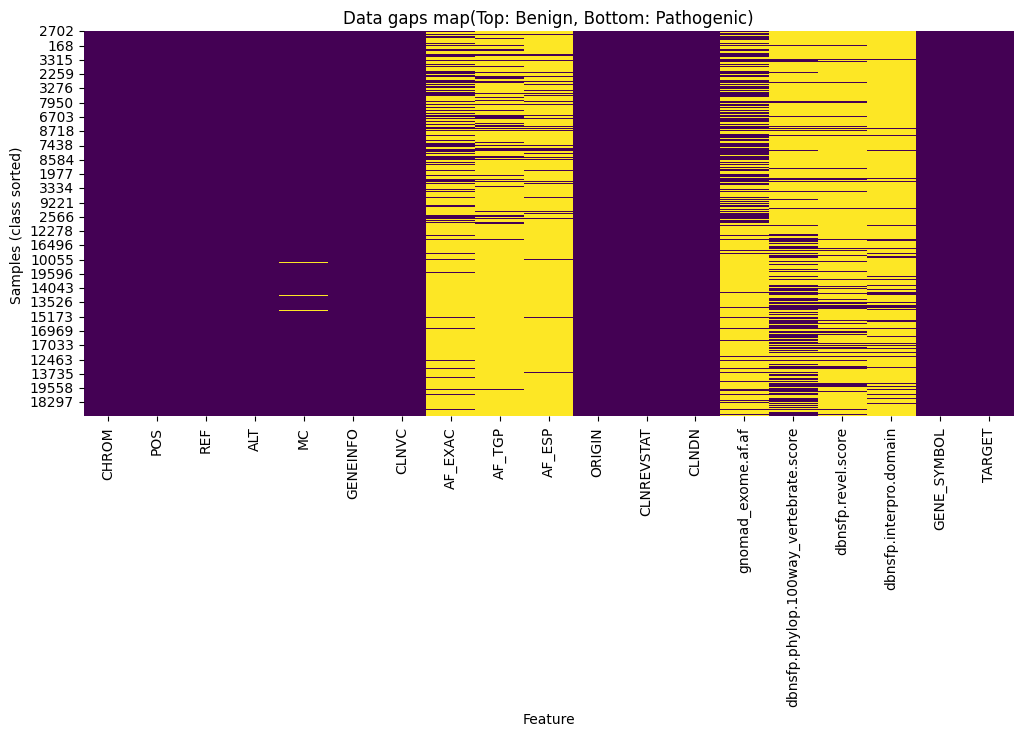

In [16]:
plt.figure(figsize=(12, 5))

sns.heatmap(X_train_eda.sort_values('TARGET').isnull(), cbar=False, cmap='viridis')
plt.title("Data gaps map(Top: Benign, Bottom: Pathogenic)")
plt.xlabel("Feature")
plt.ylabel("Samples (class sorted)")
plt.show()

In [17]:
X_train_eda['DIFF_LEN'] = X_train_eda['ALT'].str.len() - X_train_eda['REF'].str.len()

In [18]:
X_train_eda['DIFF_LEN'].value_counts()

DIFF_LEN
 0       11986
-1        1477
 1         751
-2         499
-4         191
         ...  
-5134        1
-4585        1
-3370        1
-612         1
-5838        1
Name: count, Length: 174, dtype: int64

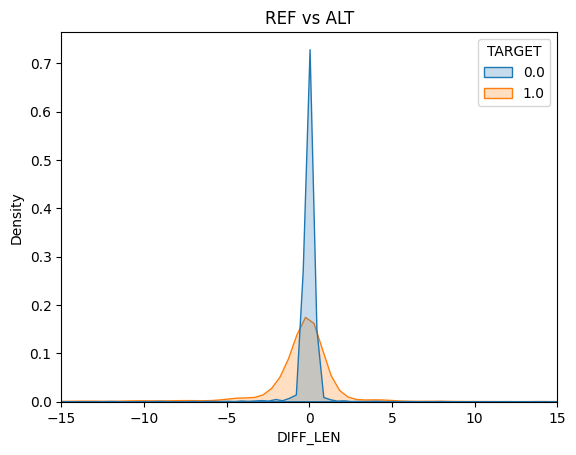

In [19]:
sns.kdeplot(data=X_train_eda[X_train_eda['DIFF_LEN'].between(-50, 50)],
            x='DIFF_LEN', hue='TARGET', fill=True)
plt.title("REF vs ALT")
plt.xlim(-15, 15)
plt.show()

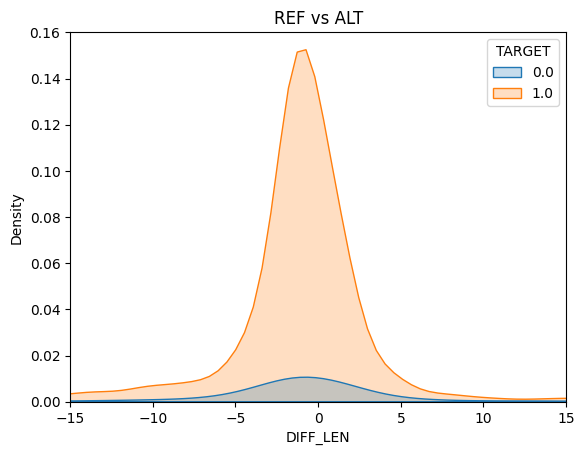

In [20]:
df_indel = X_train_eda[X_train_eda['DIFF_LEN'] != 0]
sns.kdeplot(data=df_indel[df_indel['DIFF_LEN'].between(-50, 50)],
            x='DIFF_LEN', hue='TARGET', fill=True)
plt.title("REF vs ALT")
plt.xlim(-15,15)
plt.show()

In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  object 
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15912 non-null  object 
 5   GENEINFO                               15998 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                2882 non-null   object 
 8   AF_TGP                                 1809 non-null   object 
 9   AF_ESP                                 1366 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  CLNR

In [22]:
X_train_eda['CHROM'].value_counts()

CHROM
2     1622
1     1289
17    1163
11     943
X      885
3      815
16     800
7      768
5      764
19     742
9      729
6      705
12     682
15     595
10     530
8      514
4      513
14     489
13     396
22     310
20     281
18     252
21     204
MT       8
Y        1
Name: count, dtype: int64

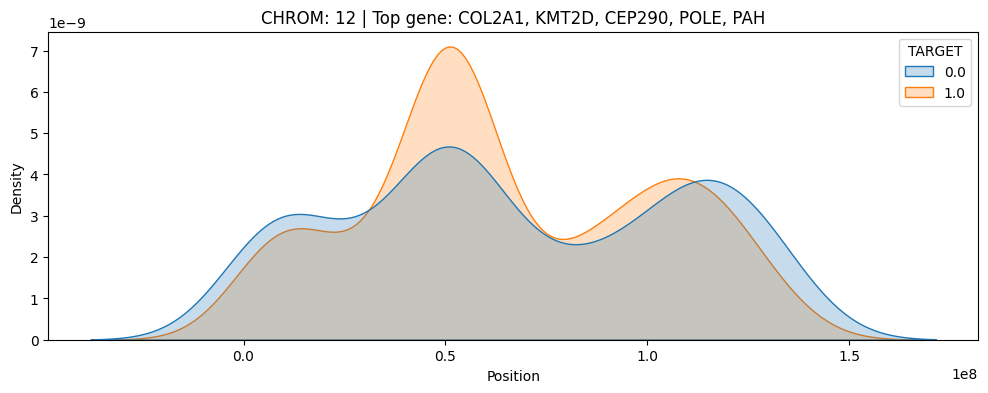

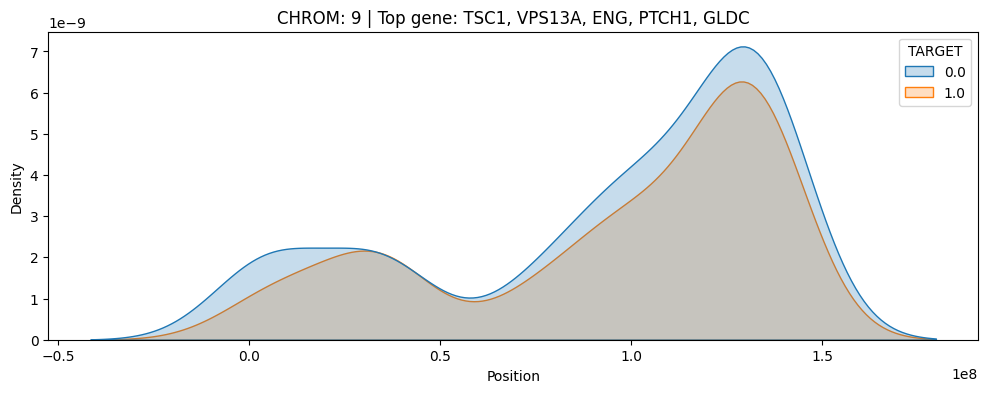

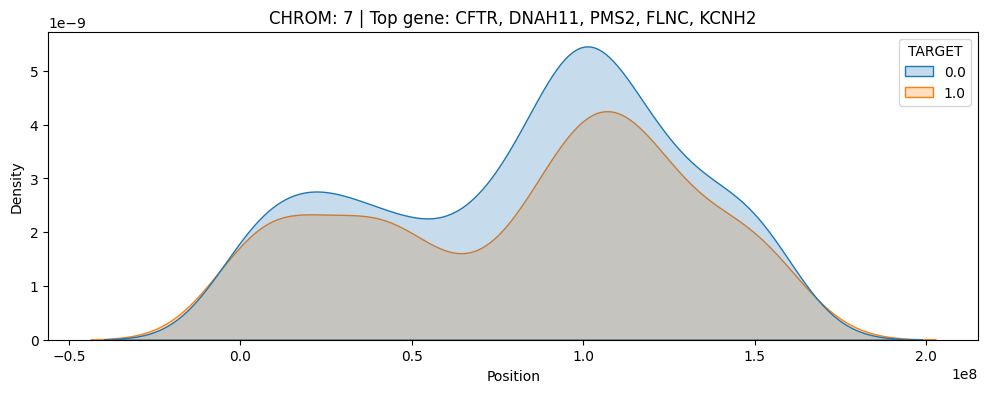

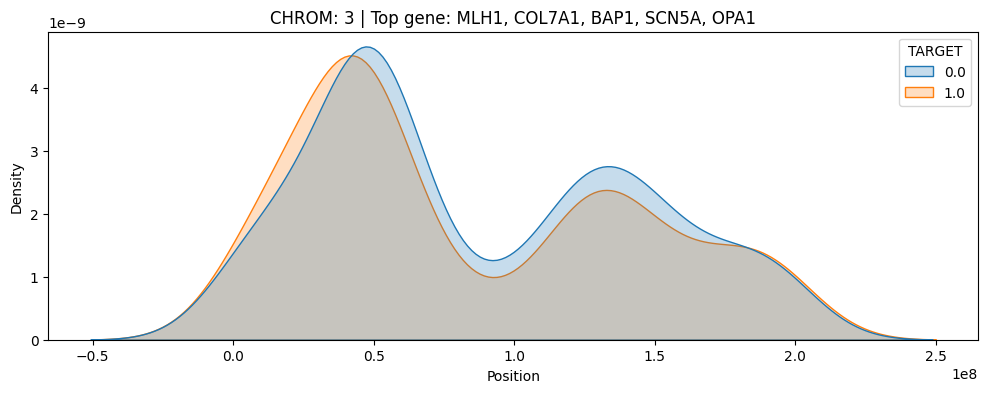

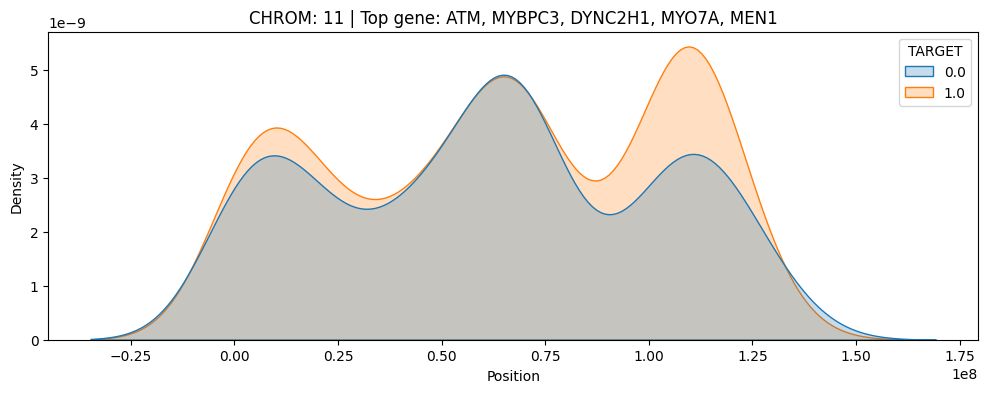

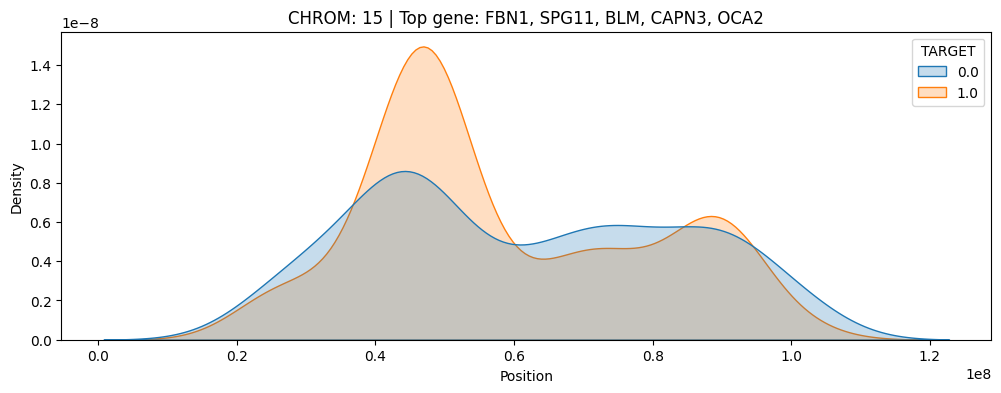

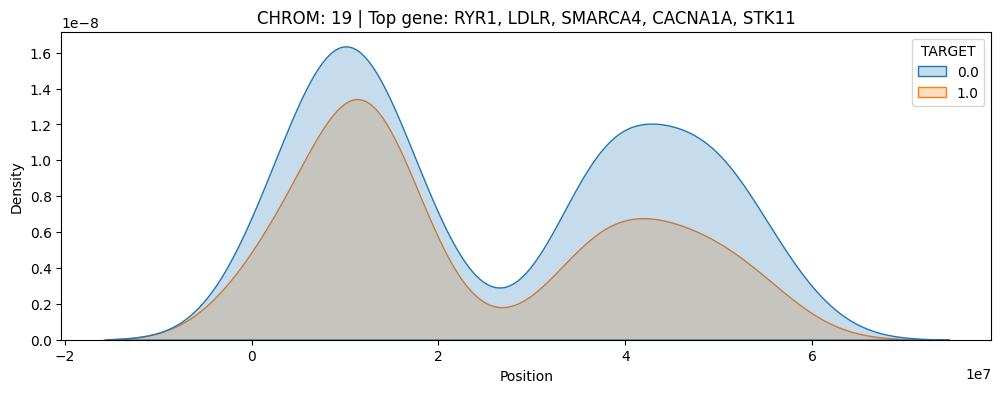

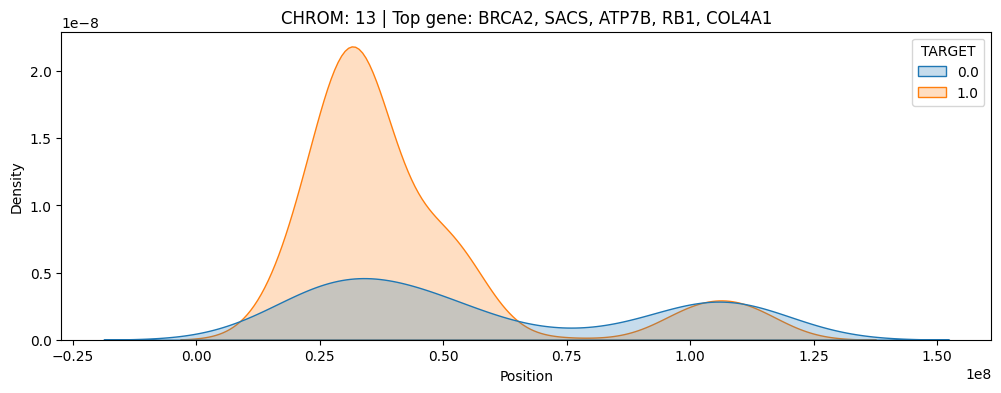

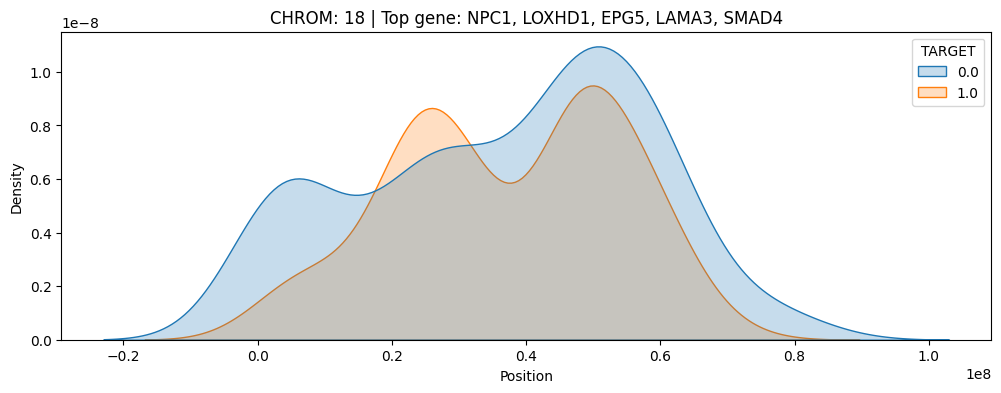

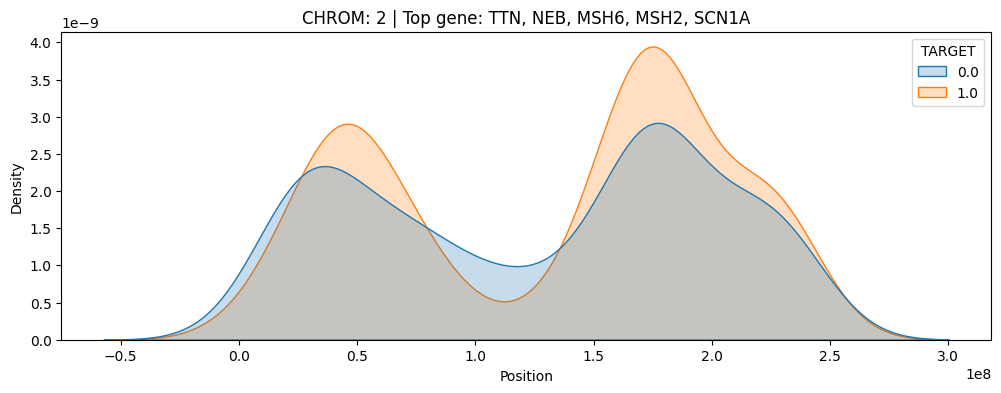

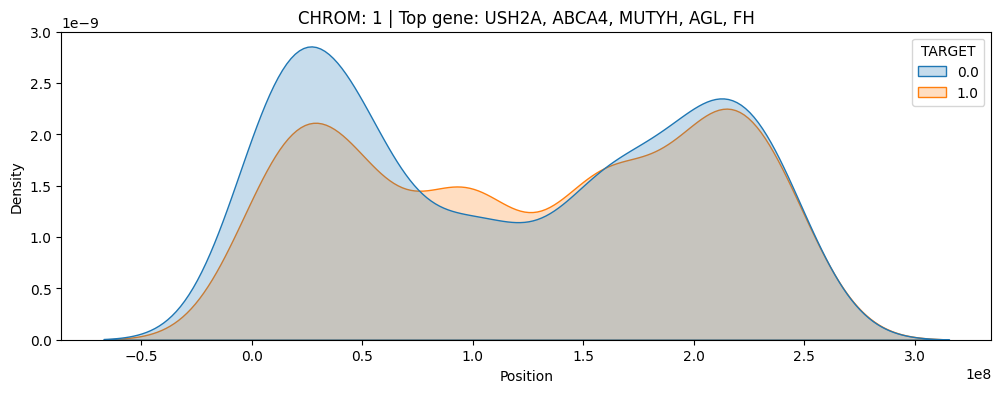

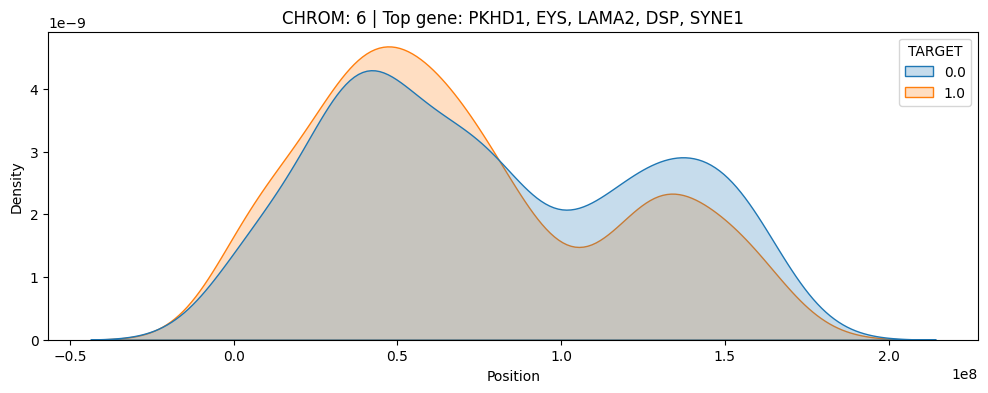

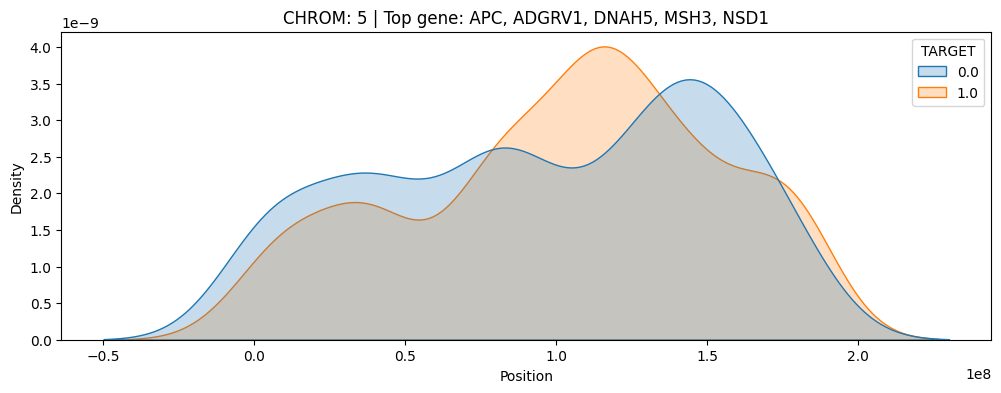

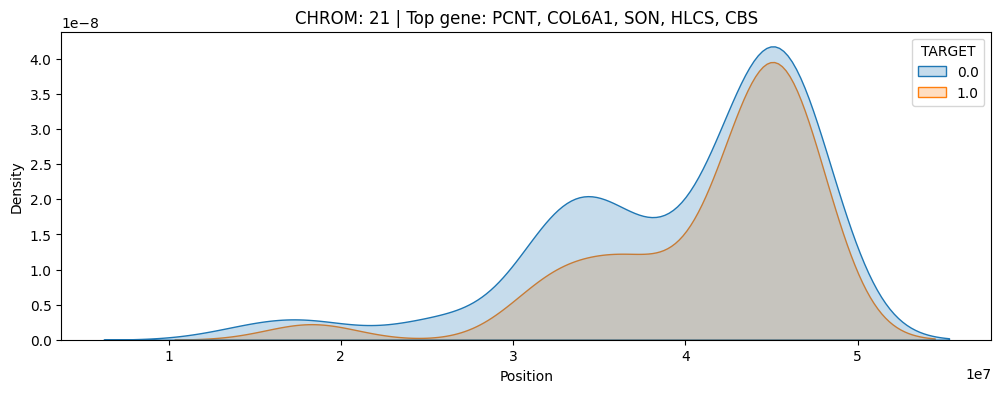

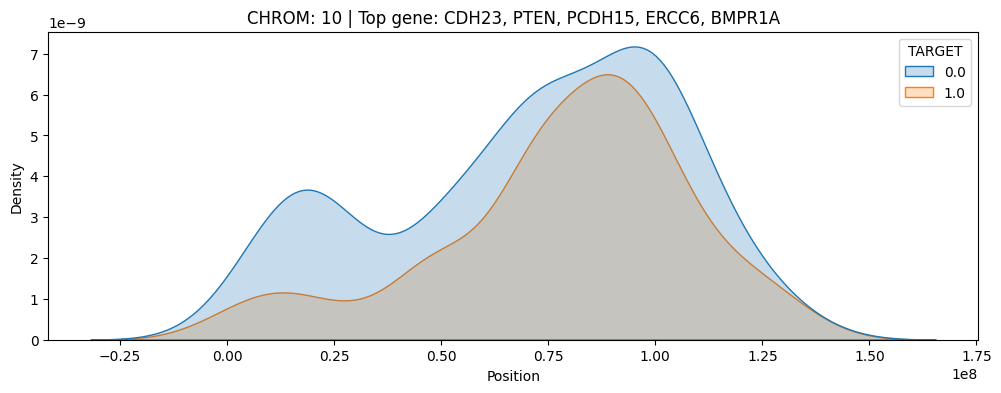

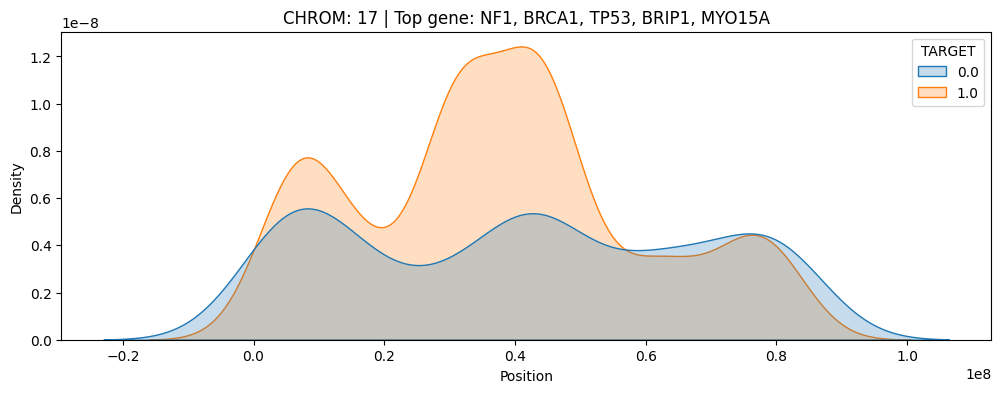

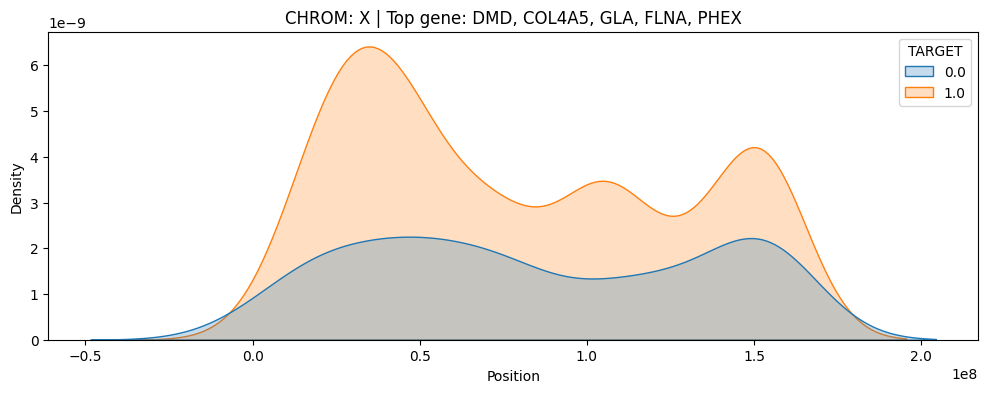

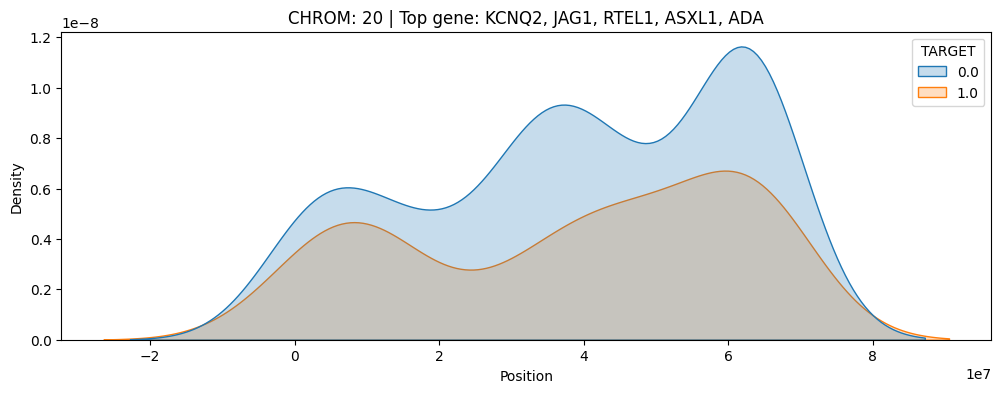

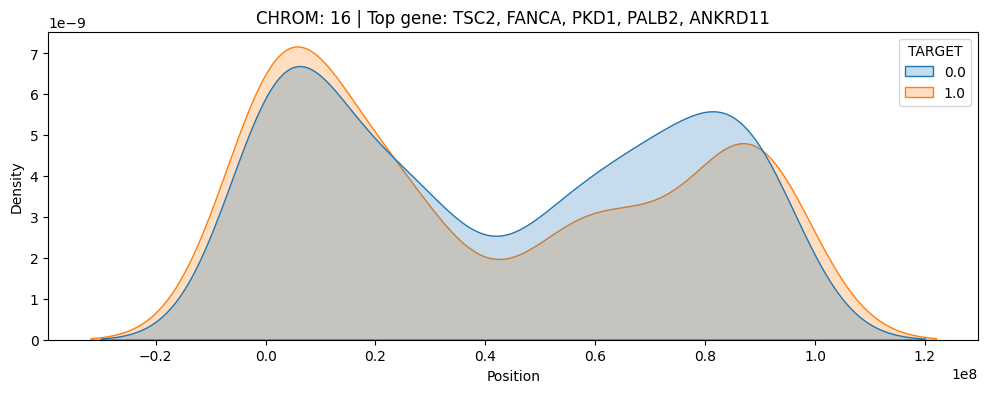

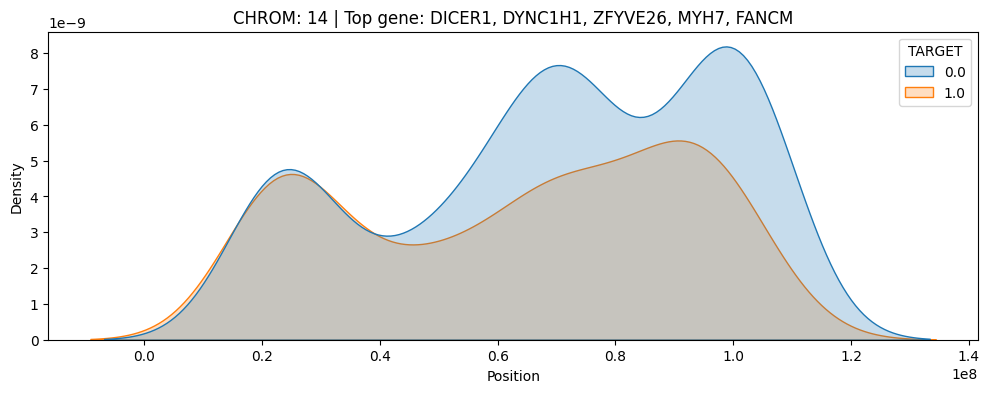

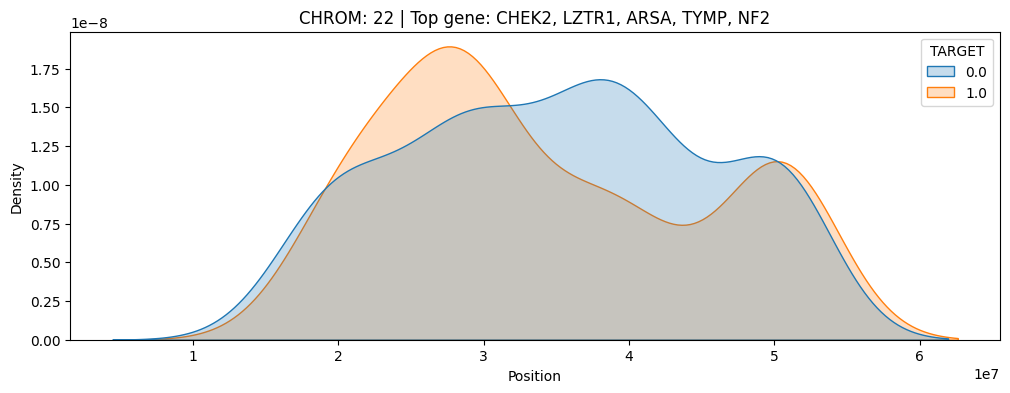

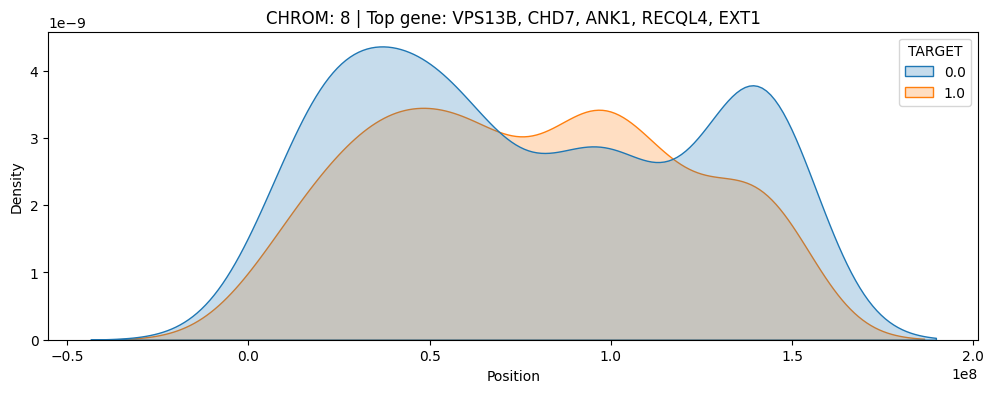

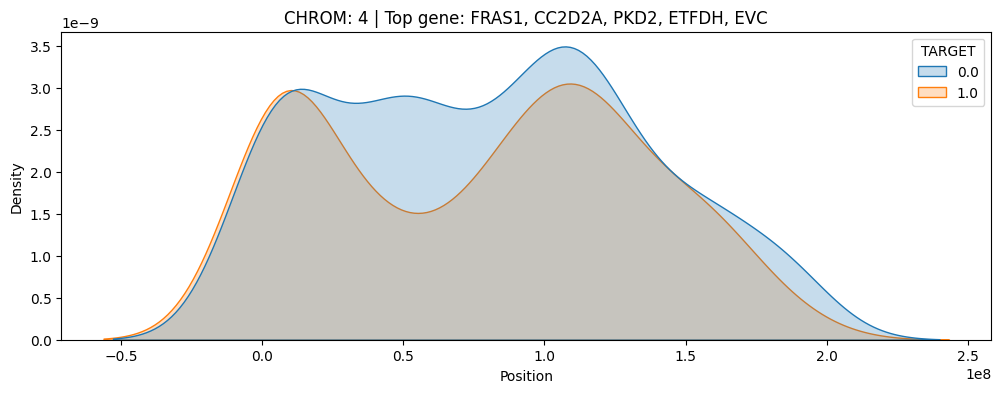

In [23]:
chroms_list = X_train_eda['CHROM'].unique().tolist()
X_train_eda['POS'] = pd.to_numeric(X_train_eda['POS'], errors='coerce')

for chrom in chroms_list: 
    subset = X_train_eda[X_train_eda['CHROM'] == chrom]
    if len(subset) < 50:
        continue
    plt.figure(figsize=(12, 4))
    sns.kdeplot(data=subset, x='POS', hue='TARGET', fill=True)
    top_genes = subset['GENE_SYMBOL'].value_counts().head().index.to_list()  
    plt.title(f'CHROM: {chrom} | Top gene: {", ".join(map(str, top_genes))}')
    plt.ylabel('Density')
    plt.xlabel('Position')
    plt.show()

In [24]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  int64  
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15912 non-null  object 
 5   GENEINFO                               15998 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                2882 non-null   object 
 8   AF_TGP                                 1809 non-null   object 
 9   AF_ESP                                 1366 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  CLNR

In [25]:
X_train_eda['is_frameshift'] = (X_train_eda['DIFF_LEN'] % 3 != 0).astype(int)

In [26]:
X_train_eda['is_frameshift'].value_counts()

is_frameshift
0    12217
1     3783
Name: count, dtype: int64

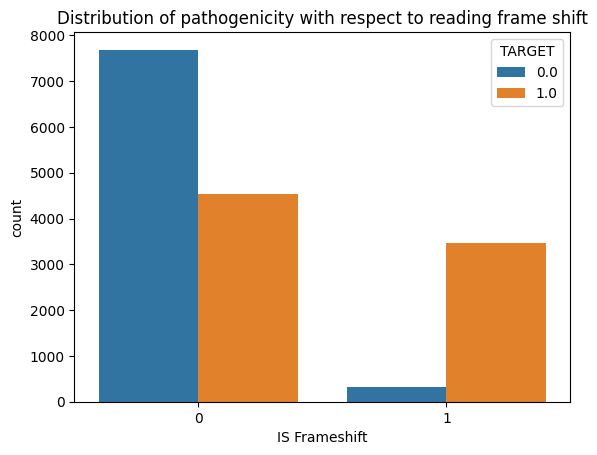

In [27]:
sns.countplot(data=X_train_eda, x='is_frameshift', hue='TARGET', fill=True)
plt.title('Distribution of pathogenicity with respect to reading frame shift')
plt.xlabel('IS Frameshift')
plt.show()

In [28]:
X_train_eda.head(15)

,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,AF_EXAC,AF_TGP,AF_ESP,...,CLNREVSTAT,CLNDN,gnomad_exome.af.af,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,dbnsfp.interpro.domain,GENE_SYMBOL,TARGET,DIFF_LEN,is_frameshift
13500,12,121827996,C,T,SO:0001583|missense_variant,SETD1B:23067,single_nucleotide_variant,None,None,None,...,"criteria_provided,_single_submitter",Intellectual_developmental_disorder_with_seizu...,NaN,2.066,0.723,SET domain|SET domain|SET domain|SET domain|SE...,SETD1B,1.0,0,0
4606,9,121006922,C,T,SO:0001583|missense_variant,C5:727,single_nucleotide_variant,0.45864,0.40475,0.32485,...,"criteria_provided,_multiple_submitters,_no_con...",not_provided|not_specified,0.471368,0.385,0.021,Alpha-2-macroglobulin|Alpha-2-macroglobulin,C5,0.0,0,0
5079,7,21842640,A,G,SO:0001819|synonymous_variant,DNAH11:8701,single_nucleotide_variant,None,None,None,...,"criteria_provided,_single_submitter",Primary_ciliary_dyskinesia,NaN,NaN,NaN,None,DNAH11,0.0,0,0
11798,3,142566138,G,GC,SO:0001589|frameshift_variant,ATR:545,Duplication,None,None,None,...,"criteria_provided,_single_submitter",not_provided,NaN,NaN,NaN,None,ATR,1.0,1,1
19966,11,119090230,C,T,SO:0001587|nonsense,HMBS:3145,single_nucleotide_variant,None,None,None,...,no_assertion_criteria_provided,Acute_intermittent_porphyria,NaN,6.470,NaN,"Porphobilinogen deaminase, N-terminal|Porphobi...",HMBS,1.0,0,0
842,15,89215244,G,A,SO:0001627|intron_variant,RLBP1:6017,single_nucleotide_variant,None,None,None,...,"criteria_provided,_single_submitter",not_provided,0.000004,NaN,NaN,None,RLBP1,0.0,0,0
15329,19,46755963,G,GA,SO:0001589|frameshift_variant,FKRP:79147,Duplication,None,None,None,...,"criteria_provided,_multiple_submitters,_no_con...",not_provided|Walker-Warburg_congenital_muscula...,NaN,NaN,NaN,None,FKRP,1.0,1,1
8299,7,95290282,C,T,SO:0001819|synonymous_variant,PPP1R9A:55607,single_nucleotide_variant,0.00017,None,0.00023,...,no_assertion_criteria_provided,PPP1R9A-related_disorder,0.000118,NaN,NaN,None,PPP1R9A,0.0,0,0
11850,13,20064531,C,CG,"SO:0001589|frameshift_variant,SO:0001619|non-c...",ZMYM2:7750,Duplication,None,None,None,...,"criteria_provided,_single_submitter",not_provided,NaN,NaN,NaN,None,ZMYM2,1.0,1,1
9895,15,89628280,G,A,SO:0001624|3_prime_UTR_variant,KIF7:374654,single_nucleotide_variant,None,0.01997,None,...,"criteria_provided,_multiple_submitters,_no_con...",not_provided|Acrocallosal_syndrome,NaN,NaN,NaN,None,KIF7,0.0,0,0


In [29]:
X_train_eda['MC'] = X_train_eda['MC'].str.extract(r'\|(\S*)')

In [30]:
X_train_eda['MC'].value_counts()

MC
synonymous_variant                                                                 3091
intron_variant                                                                     2784
frameshift_variant                                                                 2258
missense_variant                                                                   2002
nonsense                                                                           1419
                                                                                   ... 
initiator_codon_variant                                                               1
splice_acceptor_variant,SO:0001619|non-coding_transcript_variant                      1
nonsense,SO:0001619|non-coding_transcript_variant,SO:0001819|synonymous_variant       1
initiator_codon_variant,SO:0001822|inframe_deletion                                   1
nonsense,SO:0001819|synonymous_variant                                                1
Name: count, Length: 150, dty

In [31]:
X_train_eda['MC'] = X_train_eda['MC'].str.replace(r',[^|]*', '', regex=True)

In [32]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  int64  
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15912 non-null  object 
 5   GENEINFO                               15998 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                2882 non-null   object 
 8   AF_TGP                                 1809 non-null   object 
 9   AF_ESP                                 1366 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  CLNR

In [33]:
pd.set_option("display.max_rows", None)

X_train_eda['MC'].value_counts()

MC
synonymous_variant                                                                               3091
intron_variant                                                                                   2784
frameshift_variant                                                                               2258
missense_variant                                                                                 2002
nonsense                                                                                         1419
splice_donor_variant                                                                              529
non-coding_transcript_variant|synonymous_variant                                                  447
splice_acceptor_variant                                                                           443
frameshift_variant|non-coding_transcript_variant                                                  307
intron_variant|synonymous_variant                                              

In [34]:
def calc_impact_score(mc_string):
    if pd.isna(mc_string):
        return np.nan
    s = mc_string.lower()
    high_impact_keyword = ['nonsense', 'frameshift', 'splice_acceptor', 'splice_donor', 'start_lost', 'stop_lost', 'initiator_codon']
    if any(keyword in s for keyword in high_impact_keyword):
        return 2
    medium_impact_keyword = ['missense', 'inframe', 'protein_altering']
    if any(keyword in s for keyword in medium_impact_keyword):
        return 1
    return 0

X_train_eda['MC_IMPACT_SCORE'] = X_train_eda['MC'].apply(calc_impact_score)

In [35]:
X_train_eda['MC_IMPACT_SCORE'].value_counts()

MC_IMPACT_SCORE
0.0    7094
2.0    6135
1.0    2683
Name: count, dtype: int64

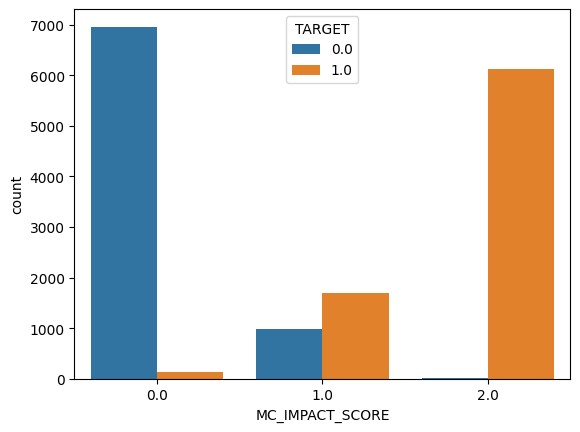

In [36]:
sns.countplot(data=X_train_eda, x='MC_IMPACT_SCORE', hue='TARGET', fill=True)
plt.xlabel('MC_IMPACT_SCORE')
plt.show()

In [37]:
cond_AG = (X_train_eda['REF'] == 'A') & (X_train_eda['ALT'] == 'G')
cond_GA = (X_train_eda['REF'] == 'G') & (X_train_eda['ALT'] == 'A')
cond_CT = (X_train_eda['REF'] == 'C') & (X_train_eda['ALT'] == 'T')
cond_TC = (X_train_eda['REF'] == 'T') & (X_train_eda['ALT'] == 'C')

X_train_eda['is_transition'] = (cond_AG | cond_GA | cond_CT | cond_TC).astype(int)

In [38]:
X_train_eda['is_transition'].value_counts()

is_transition
0    8258
1    7742
Name: count, dtype: int64

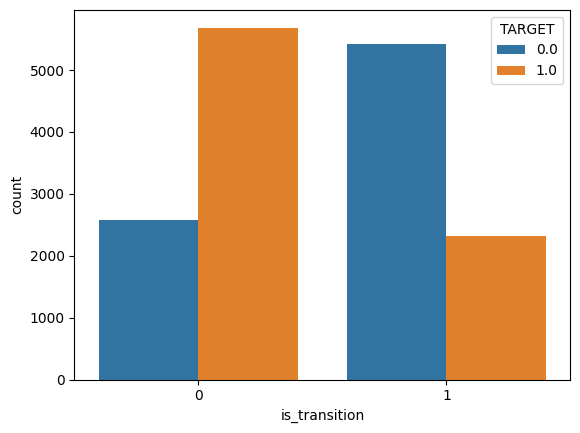

In [39]:
sns.countplot(data=X_train_eda, x='is_transition', hue='TARGET', fill=True)
plt.xlabel('is_transition')
plt.show()

In [40]:
X_train_eda = X_train_eda.drop(columns=['CLNREVSTAT', 'CLNDN'], axis=1)

In [41]:
gene_stats = X_train_eda.groupby('GENE_SYMBOL')['TARGET'].agg(['count', 'mean'])
global_mean = X_train_eda['TARGET'].mean()
m=10
smooth_map = (gene_stats['count'] * gene_stats['mean'] + m * global_mean) / (gene_stats['count'] + m)
X_train_eda['GENE_RISK'] = X_train_eda['GENE_SYMBOL'].map(smooth_map)
X_train_eda['GENE_RISK'] = X_train_eda['GENE_RISK'].fillna(global_mean)
X_train_eda = X_train_eda.drop(columns=['GENE_SYMBOL'], axis=1)

In [42]:
X_train_eda['GENE_RISK'].head(20)

13500    0.600000
4606     0.375000
5079     0.458333
11798    0.380952
19966    0.500000
842      0.500000
15329    0.588235
8299     0.454545
11850    0.687500
9895     0.411765
16271    0.545455
17777    0.841176
13638    0.466667
14126    0.562500
12399    0.558140
4010     0.454545
10166    0.555556
15033    0.529412
17114    0.533333
18486    0.425000
Name: GENE_RISK, dtype: float64

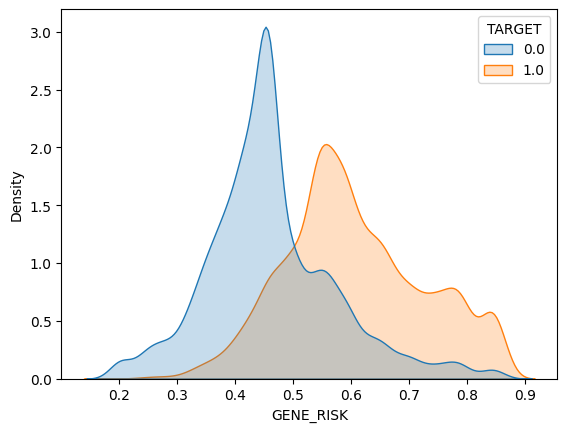

In [43]:
sns.kdeplot(data=X_train_eda, x='GENE_RISK', hue='TARGET', fill=True)
plt.show()

In [44]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  int64  
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15912 non-null  object 
 5   GENEINFO                               15998 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   AF_EXAC                                2882 non-null   object 
 8   AF_TGP                                 1809 non-null   object 
 9   AF_ESP                                 1366 non-null   object 
 10  ORIGIN                                 16000 non-null  object 
 11  gnom

In [45]:
af_cols = ['AF_EXAC', 'AF_TGP', 'AF_ESP', 'gnomad_exome.af.af']
for col in af_cols:
    X_train_eda[col] = X_train_eda[col].fillna(0)
    X_train_eda[col] = pd.to_numeric(X_train_eda[col], errors='coerce')

X_train_eda['MAX_AF'] = X_train_eda[af_cols].max(axis=1)
X_train_eda = X_train_eda.drop(columns=af_cols, axis=1)

In [46]:
X_train_eda.head(20)

,CHROM,POS,REF,ALT,MC,GENEINFO,CLNVC,ORIGIN,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,dbnsfp.interpro.domain,TARGET,DIFF_LEN,is_frameshift,MC_IMPACT_SCORE,is_transition,GENE_RISK,MAX_AF
13500,12,121827996,C,T,missense_variant,SETD1B:23067,single_nucleotide_variant,1,2.066,0.723,SET domain|SET domain|SET domain|SET domain|SE...,1.0,0,0,1.0,1,0.600000,0.000000
4606,9,121006922,C,T,missense_variant,C5:727,single_nucleotide_variant,1,0.385,0.021,Alpha-2-macroglobulin|Alpha-2-macroglobulin,0.0,0,0,1.0,1,0.375000,0.471368
5079,7,21842640,A,G,synonymous_variant,DNAH11:8701,single_nucleotide_variant,1,NaN,NaN,None,0.0,0,0,0.0,1,0.458333,0.000000
11798,3,142566138,G,GC,frameshift_variant,ATR:545,Duplication,1,NaN,NaN,None,1.0,1,1,2.0,0,0.380952,0.000000
19966,11,119090230,C,T,nonsense,HMBS:3145,single_nucleotide_variant,1,6.470,NaN,"Porphobilinogen deaminase, N-terminal|Porphobi...",1.0,0,0,2.0,1,0.500000,0.000000
842,15,89215244,G,A,intron_variant,RLBP1:6017,single_nucleotide_variant,1,NaN,NaN,None,0.0,0,0,0.0,1,0.500000,0.000004
15329,19,46755963,G,GA,frameshift_variant,FKRP:79147,Duplication,1,NaN,NaN,None,1.0,1,1,2.0,0,0.588235,0.000000
8299,7,95290282,C,T,synonymous_variant,PPP1R9A:55607,single_nucleotide_variant,1,NaN,NaN,None,0.0,0,0,0.0,1,0.454545,0.000230
11850,13,20064531,C,CG,frameshift_variant|non-coding_transcript_variant,ZMYM2:7750,Duplication,1,NaN,NaN,None,1.0,1,1,2.0,0,0.687500,0.000000
9895,15,89628280,G,A,3_prime_UTR_variant,KIF7:374654,single_nucleotide_variant,1,NaN,NaN,None,0.0,0,0,0.0,1,0.411765,0.019970


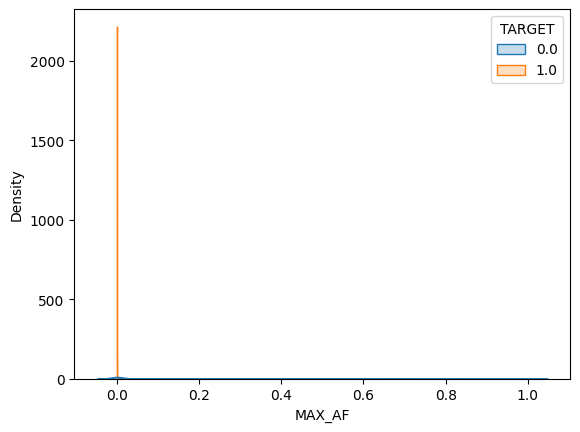

In [47]:
sns.kdeplot(data=X_train_eda, x='MAX_AF', hue='TARGET', fill=True)
plt.show()

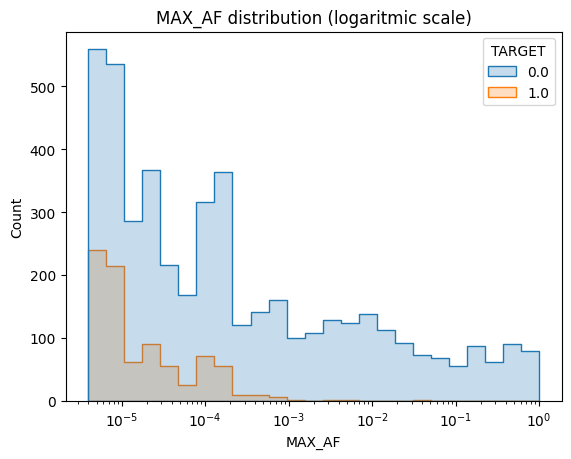

In [48]:
sns.histplot(data=X_train_eda, x='MAX_AF', hue='TARGET', log_scale=True, element="step")
plt.title("MAX_AF distribution (logaritmic scale)")
plt.show()

In [49]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  object 
 1   POS                                    16000 non-null  int64  
 2   REF                                    16000 non-null  object 
 3   ALT                                    16000 non-null  object 
 4   MC                                     15912 non-null  object 
 5   GENEINFO                               15998 non-null  object 
 6   CLNVC                                  16000 non-null  object 
 7   ORIGIN                                 16000 non-null  object 
 8   dbnsfp.phylop.100way_vertebrate.score  5193 non-null   float64
 9   dbnsfp.revel.score                     2537 non-null   float64
 10  dbnsfp.interpro.domain                 1918 non-null   object 
 11  TARG

In [50]:
X_train_eda['CHROM'].value_counts()

CHROM
2     1622
1     1289
17    1163
11     943
X      885
3      815
16     800
7      768
5      764
19     742
9      729
6      705
12     682
15     595
10     530
8      514
4      513
14     489
13     396
22     310
20     281
18     252
21     204
MT       8
Y        1
Name: count, dtype: int64

In [51]:
chrom_map = {
    'X': 23,
    'Y': 24,
    'MT': 25, 
    'M': 25,
    'Mit': 25,
    'NT_187693.1': 99
}
X_train_eda['CHROM'] = X_train_eda['CHROM'].astype(str).replace(chrom_map)


In [52]:
X_train_eda['CHROM'] = X_train_eda['CHROM'].astype(int)

In [53]:
X_train_eda = X_train_eda.drop(columns=['POS', 'REF', 'ALT', 'MC', 'GENEINFO', 'CLNVC'], axis=1)

In [54]:
X_train_eda['ORIGIN'].value_counts()

ORIGIN
1     14659
0       659
32      159
33      111
4        77
5        74
16       51
17       47
3        33
9        29
2        29
8        26
65       12
64        9
41        4
37        4
29        3
25        3
35        3
24        2
49        2
61        1
13        1
34        1
20        1
Name: count, dtype: int64

In [55]:
top_origins = X_train_eda['ORIGIN'].value_counts()
common_origin = top_origins[top_origins >= 50].index
X_train_eda['ORIGIN_GROUPED'] = X_train_eda['ORIGIN'].apply(lambda x: x if x in common_origin else 999)

X_train_eda = pd.get_dummies(X_train_eda, columns=['ORIGIN_GROUPED'], prefix='ORIGIN')
if 'ORIGIN' in X_train_eda.columns:
    X_train_eda = X_train_eda.drop(columns=['ORIGIN'])

In [56]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   dbnsfp.phylop.100way_vertebrate.score  5193 non-null   float64
 2   dbnsfp.revel.score                     2537 non-null   float64
 3   dbnsfp.interpro.domain                 1918 non-null   object 
 4   TARGET                                 16000 non-null  float64
 5   DIFF_LEN                               16000 non-null  int64  
 6   is_frameshift                          16000 non-null  int64  
 7   MC_IMPACT_SCORE                        15912 non-null  float64
 8   is_transition                          16000 non-null  int64  
 9   GENE_RISK                              16000 non-null  float64
 10  MAX_AF                                 16000 non-null  float64
 11  ORIG

In [57]:
X_train_eda['is_in_critical_domain'] = X_train_eda['dbnsfp.interpro.domain'].notna().astype(int)
X_train_eda = X_train_eda.drop(columns=['dbnsfp.interpro.domain'], axis=1)

score_cols = ['dbnsfp.phylop.100way_vertebrate.score', 'dbnsfp.revel.score']
X_train_eda[score_cols] = X_train_eda[score_cols].fillna(-1)

In [58]:
X_train_eda['MC_IMPACT_SCORE'] = X_train_eda['MC_IMPACT_SCORE'].fillna(0)
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 2   dbnsfp.revel.score                     16000 non-null  float64
 3   TARGET                                 16000 non-null  float64
 4   DIFF_LEN                               16000 non-null  int64  
 5   is_frameshift                          16000 non-null  int64  
 6   MC_IMPACT_SCORE                        16000 non-null  float64
 7   is_transition                          16000 non-null  int64  
 8   GENE_RISK                              16000 non-null  float64
 9   MAX_AF                                 16000 non-null  float64
 10  ORIGIN_999                             16000 non-null  bool   
 11  ORIG

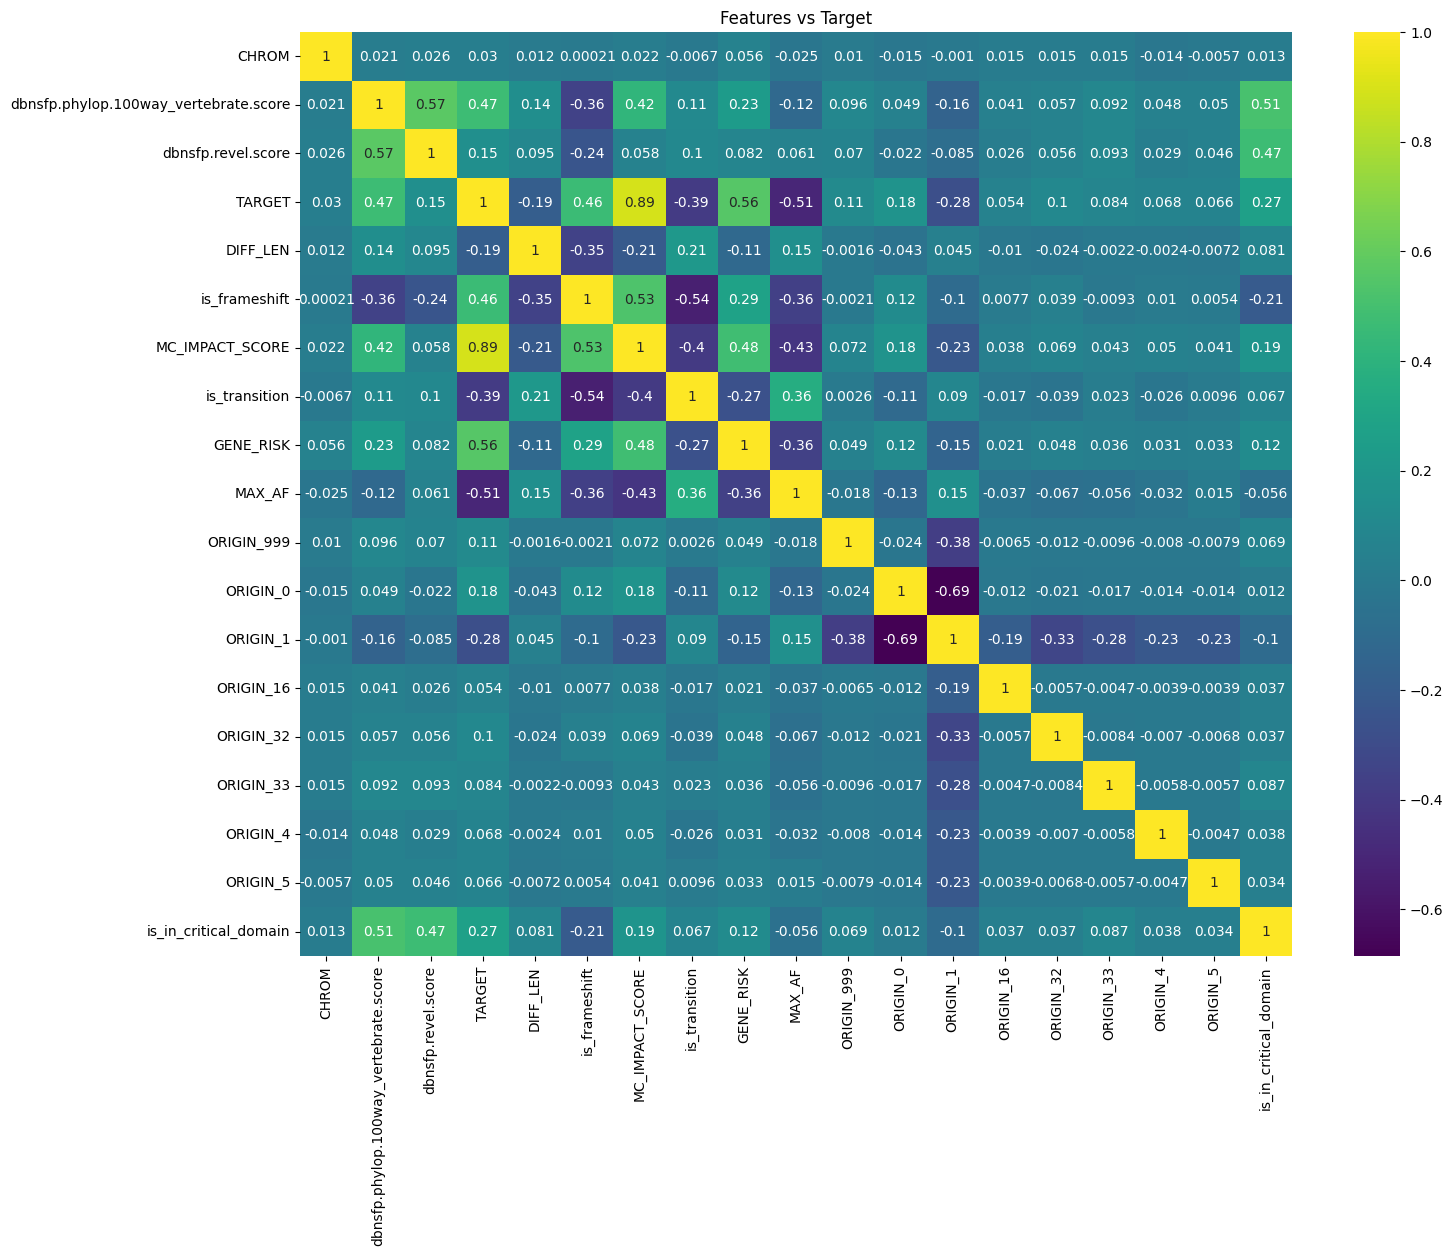

In [59]:
corr_matrix = X_train_eda.corr(method='spearman')
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='viridis')
plt.title('Features vs Target')
plt.show()

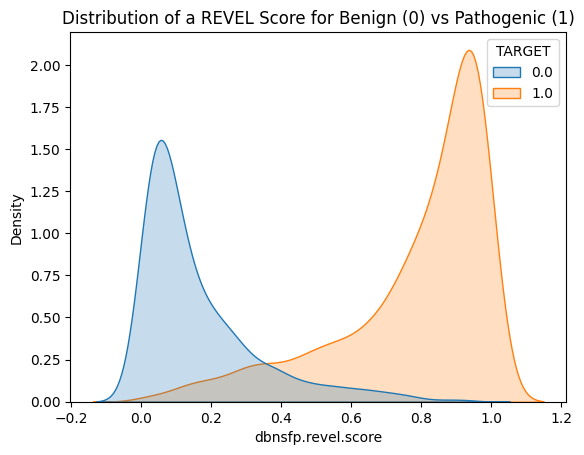

In [60]:
sns.kdeplot(data=X_train_eda[X_train_eda['dbnsfp.revel.score'] != -1], 
            x='dbnsfp.revel.score', hue='TARGET', fill=True)
plt.title("Distribution of a REVEL Score for Benign (0) vs Pathogenic (1)")
plt.show()

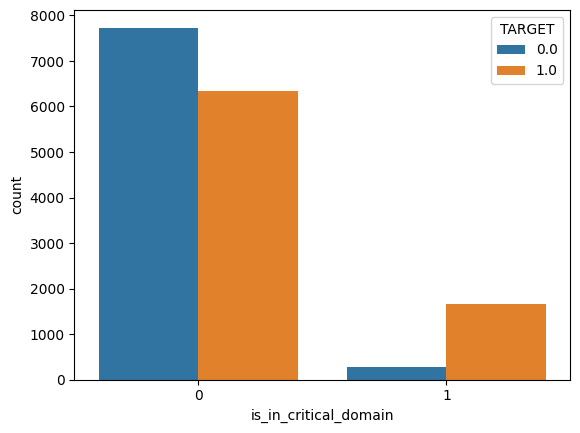

In [61]:
sns.countplot(data=X_train_eda, x='is_in_critical_domain', hue='TARGET')
plt.show()

In [62]:
X_train_eda.head()

,CHROM,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,TARGET,DIFF_LEN,is_frameshift,MC_IMPACT_SCORE,is_transition,GENE_RISK,MAX_AF,ORIGIN_999,ORIGIN_0,ORIGIN_1,ORIGIN_16,ORIGIN_32,ORIGIN_33,ORIGIN_4,ORIGIN_5,is_in_critical_domain
13500,12,2.066,0.723,1.0,0,0,1.0,1,0.600000,0.000000,False,False,True,False,False,False,False,False,1
4606,9,0.385,0.021,0.0,0,0,1.0,1,0.375000,0.471368,False,False,True,False,False,False,False,False,1
5079,7,-1.000,-1.000,0.0,0,0,0.0,1,0.458333,0.000000,False,False,True,False,False,False,False,False,0
11798,3,-1.000,-1.000,1.0,1,1,2.0,0,0.380952,0.000000,False,False,True,False,False,False,False,False,0
19966,11,6.470,-1.000,1.0,0,0,2.0,1,0.500000,0.000000,False,False,True,False,False,False,False,False,1


In [63]:
origin_cols = ['ORIGIN_0','ORIGIN_1','ORIGIN_4', 'ORIGIN_5', 'ORIGIN_32', 'ORIGIN_33', 'ORIGIN_999']
X_train_eda[origin_cols] = X_train_eda[origin_cols].astype(int)

In [64]:
X_train_eda.head()

,CHROM,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,TARGET,DIFF_LEN,is_frameshift,MC_IMPACT_SCORE,is_transition,GENE_RISK,MAX_AF,ORIGIN_999,ORIGIN_0,ORIGIN_1,ORIGIN_16,ORIGIN_32,ORIGIN_33,ORIGIN_4,ORIGIN_5,is_in_critical_domain
13500,12,2.066,0.723,1.0,0,0,1.0,1,0.600000,0.000000,0,0,1,False,0,0,0,0,1
4606,9,0.385,0.021,0.0,0,0,1.0,1,0.375000,0.471368,0,0,1,False,0,0,0,0,1
5079,7,-1.000,-1.000,0.0,0,0,0.0,1,0.458333,0.000000,0,0,1,False,0,0,0,0,0
11798,3,-1.000,-1.000,1.0,1,1,2.0,0,0.380952,0.000000,0,0,1,False,0,0,0,0,0
19966,11,6.470,-1.000,1.0,0,0,2.0,1,0.500000,0.000000,0,0,1,False,0,0,0,0,1


In [65]:
X_train_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 2   dbnsfp.revel.score                     16000 non-null  float64
 3   TARGET                                 16000 non-null  float64
 4   DIFF_LEN                               16000 non-null  int64  
 5   is_frameshift                          16000 non-null  int64  
 6   MC_IMPACT_SCORE                        16000 non-null  float64
 7   is_transition                          16000 non-null  int64  
 8   GENE_RISK                              16000 non-null  float64
 9   MAX_AF                                 16000 non-null  float64
 10  ORIGIN_999                             16000 non-null  int64  
 11  ORIG

In [66]:
X_train_eda['MC_IMPACT_SCORE'].value_counts()

MC_IMPACT_SCORE
0.0    7182
2.0    6135
1.0    2683
Name: count, dtype: int64

In [67]:
X_train_eda['is_in_critical_domain'].value_counts()

is_in_critical_domain
0    14082
1     1918
Name: count, dtype: int64

In [68]:
class AddAcmgRules(BaseEstimator, TransformerMixin):
    def __init__(self, af_threshold_benign=0.05, revel_threshold_pathogenic=0.75):
        self.af_threshold_benign = af_threshold_benign
        self.revel_threshold_pathogenic = revel_threshold_pathogenic
        

    def fit(self, X, y=None):
        return self
    
    def _apply_population_rules(self, df):
        df['ACMG_BA1'] = (df['MAX_AF'] > self.af_threshold_benign).astype(int)
        df['ACMG_BS1'] = ((df['MAX_AF'] > 0.01) & (df['MAX_AF'] <= self.af_threshold_benign)).astype(int)
        df['ACMG_PM2'] = (df['MAX_AF'] < 0.0001).astype(int)
        return df
    
    def _apply_structural_rules(self, df):
        df['ACMG_PSV1'] = (df['MC_IMPACT_SCORE'] == 2.0).astype(int)
        df['ACMG_PM4'] = ((df['DIFF_LEN'] != 0) & (df['is_frameshift'] == 0) & (df['MC_IMPACT_SCORE'] != 2.0)).astype(int)
        return df
    
    def _apply_computational_rules(self, df):
        col = 'dbnsfp.revel.score'
        df['ACMG_PP3'] = ((df[col] > self.revel_threshold_pathogenic) & (df[col] != -1)).astype(int)
        return df
    
    def _apply_domain_rules(self, df):
        df['ACMG_PM1'] = df['is_in_critical_domain']
        return df

    def _apply_evolution_rules(self, df):
        df['ACMG_PP2'] = ((df['dbnsfp.phylop.100way_vertebrate.score'] > 2.0) & (df['MC_IMPACT_SCORE'] == 1.0)).astype(int)
        return df 

    def _apply_origin_rules(self, df):
        df['ACMG_PS2'] = ((df['ORIGIN_32'] == 1) | (df['ORIGIN_33'] == 1)).astype(int)
        return df
    
    def _apply_synonumous_rules(self, df):
        is_synonymous = (df['MC_IMPACT_SCORE'] == 0)
        is_safe = True
        is_safe = ((df['dbnsfp.revel.score'] < 0.05) | (df['dbnsfp.revel.score'] == -1))
        df['ACMG_BP7'] = (is_safe & is_synonymous).astype(int)
        return df
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy = self._apply_population_rules(X_copy)
        X_copy = self._apply_structural_rules(X_copy)
        X_copy = self._apply_domain_rules(X_copy)
        X_copy = self._apply_computational_rules(X_copy)
        X_copy = self._apply_evolution_rules(X_copy)
        X_copy = self._apply_origin_rules(X_copy)
        X_copy = self._apply_synonumous_rules(X_copy)
        return X_copy
    

In [69]:
acmg_transformer = AddAcmgRules()
X_train_eda_acmg = acmg_transformer.transform(X_train_eda)

In [70]:
X_train_eda_acmg.head()

,CHROM,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,TARGET,DIFF_LEN,is_frameshift,MC_IMPACT_SCORE,is_transition,GENE_RISK,MAX_AF,...,ACMG_BA1,ACMG_BS1,ACMG_PM2,ACMG_PSV1,ACMG_PM4,ACMG_PM1,ACMG_PP3,ACMG_PP2,ACMG_PS2,ACMG_BP7
13500,12,2.066,0.723,1.0,0,0,1.0,1,0.600000,0.000000,...,0,0,1,0,0,1,0,1,0,0
4606,9,0.385,0.021,0.0,0,0,1.0,1,0.375000,0.471368,...,1,0,0,0,0,1,0,0,0,0
5079,7,-1.000,-1.000,0.0,0,0,0.0,1,0.458333,0.000000,...,0,0,1,0,0,0,0,0,0,1
11798,3,-1.000,-1.000,1.0,1,1,2.0,0,0.380952,0.000000,...,0,0,1,1,0,0,0,0,0,0
19966,11,6.470,-1.000,1.0,0,0,2.0,1,0.500000,0.000000,...,0,0,1,1,0,1,0,0,0,0


In [71]:
X_train_eda_acmg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 2   dbnsfp.revel.score                     16000 non-null  float64
 3   TARGET                                 16000 non-null  float64
 4   DIFF_LEN                               16000 non-null  int64  
 5   is_frameshift                          16000 non-null  int64  
 6   MC_IMPACT_SCORE                        16000 non-null  float64
 7   is_transition                          16000 non-null  int64  
 8   GENE_RISK                              16000 non-null  float64
 9   MAX_AF                                 16000 non-null  float64
 10  ORIGIN_999                             16000 non-null  int64  
 11  ORIG

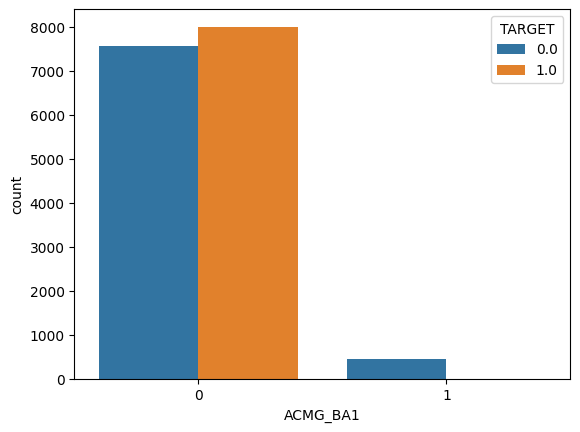

In [72]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_BA1', hue='TARGET')
plt.show()


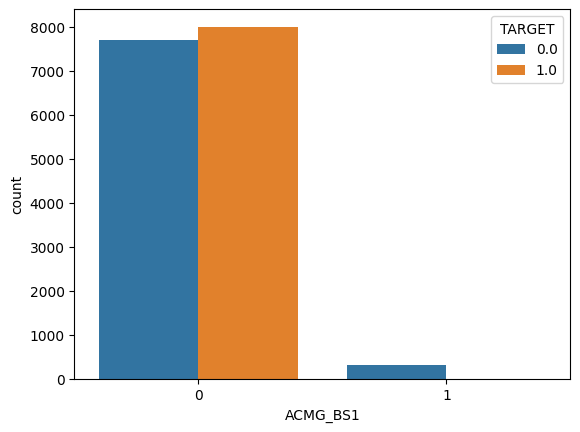

In [73]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_BS1', hue='TARGET')
plt.show()

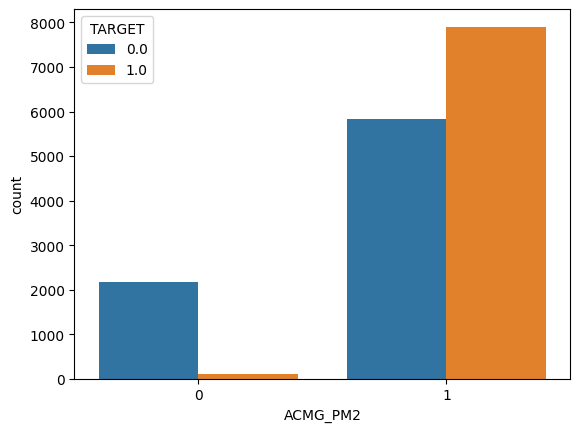

In [74]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PM2', hue='TARGET')
plt.show()

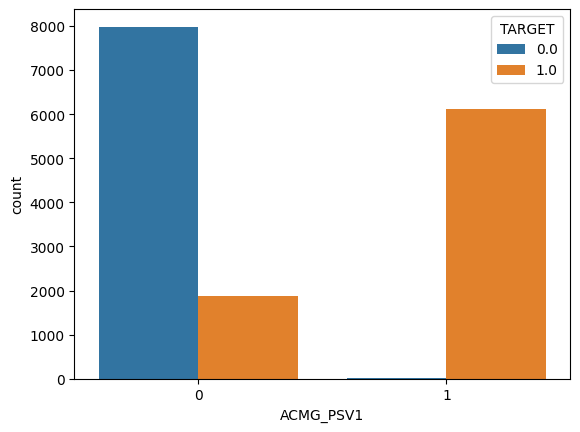

In [75]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PSV1', hue='TARGET')
plt.show()

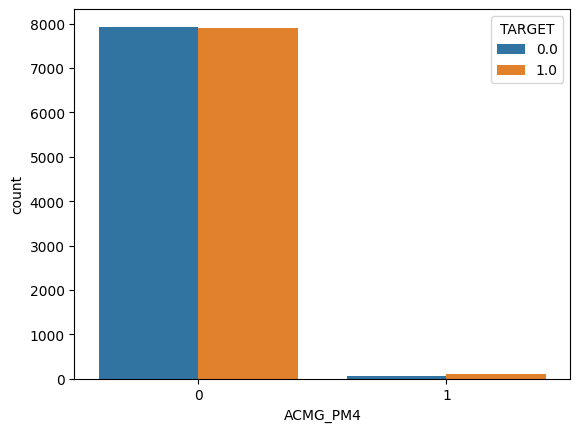

In [76]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PM4', hue='TARGET')
plt.show()

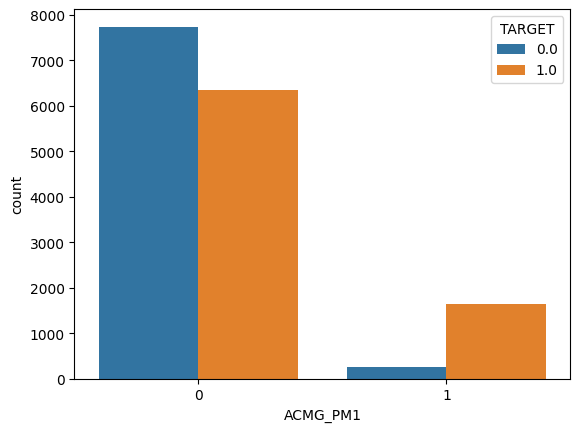

In [77]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PM1', hue='TARGET')
plt.show()

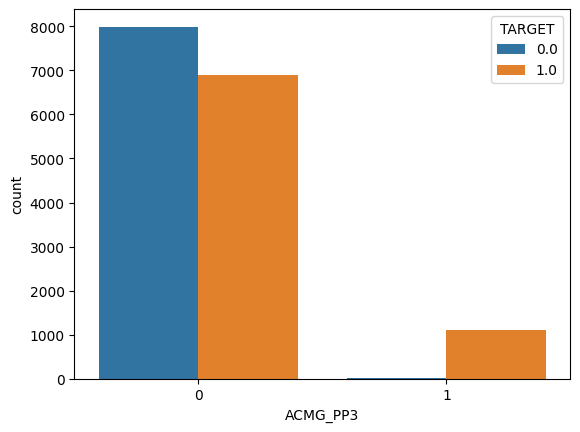

In [78]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PP3', hue='TARGET')
plt.show()

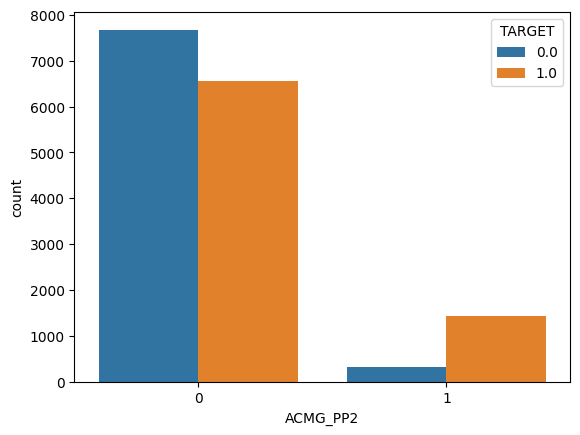

In [79]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PP2', hue='TARGET')
plt.show()

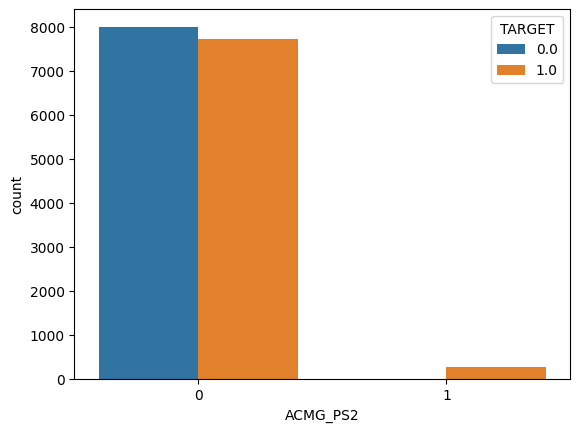

In [80]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_PS2', hue='TARGET')
plt.show()

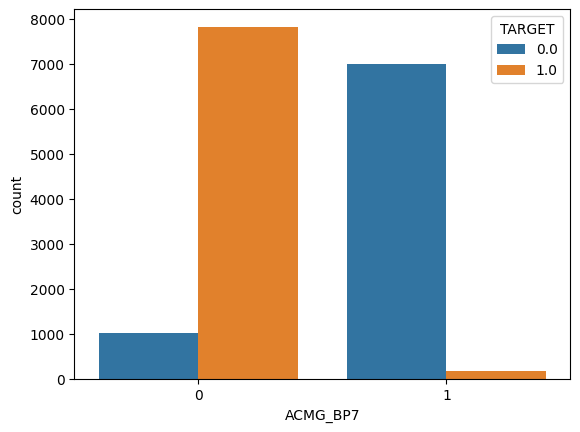

In [81]:
sns.countplot(data=X_train_eda_acmg, x='ACMG_BP7', hue='TARGET')
plt.show()

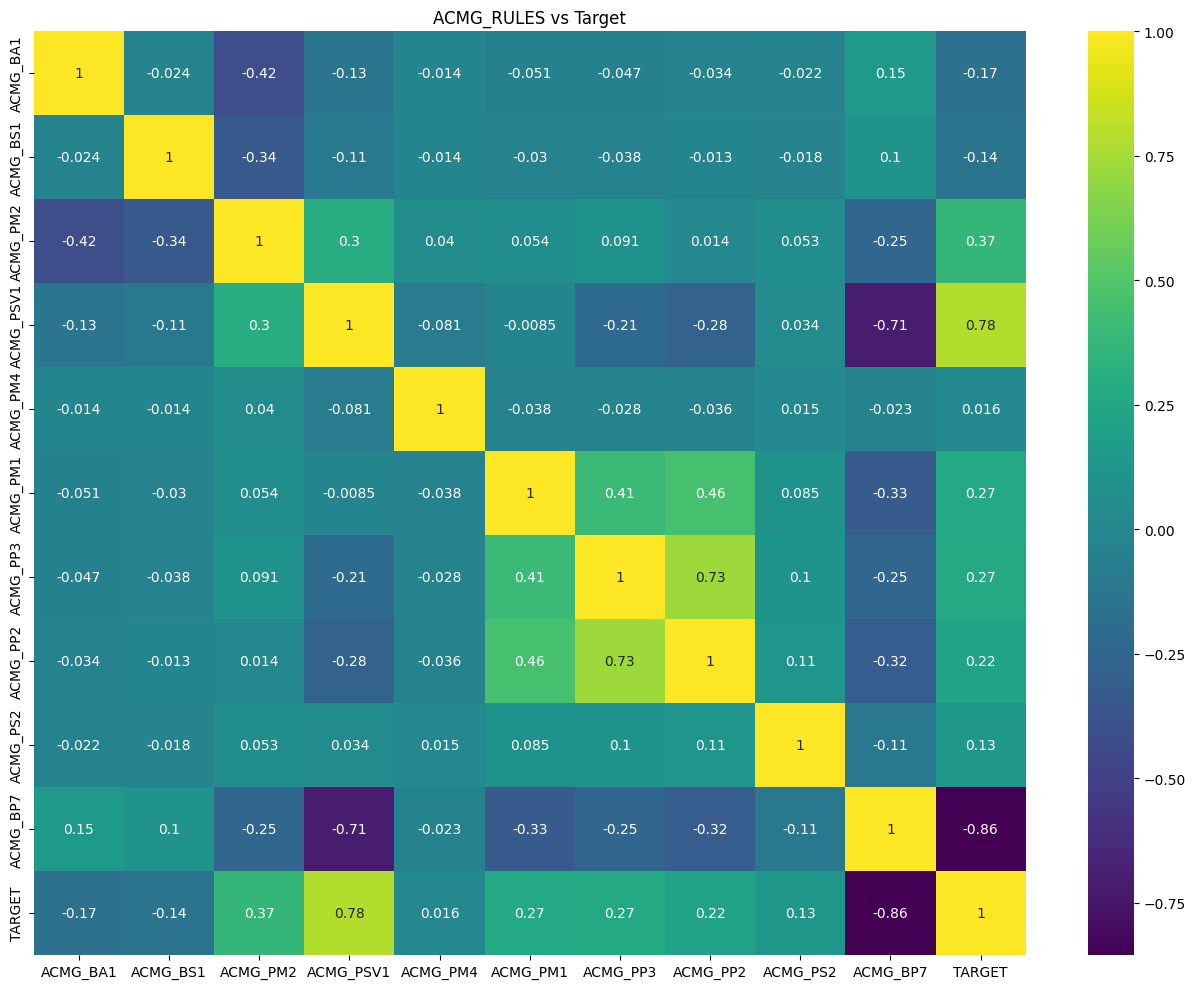

In [82]:
acmg_cols = [c for c in X_train_eda_acmg.columns if 'ACMG' in c]
cols_to_plot = acmg_cols + ['TARGET']

corr_matrix = X_train_eda_acmg[cols_to_plot].corr(method='spearman')
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='viridis')
plt.title('ACMG_RULES vs Target')
plt.show()

In [83]:
class AddAcmgRules(BaseEstimator, TransformerMixin):
    def __init__(self, af_threshold_benign=0.05, revel_threshold_pathogenic=0.75):
        self.af_threshold_benign = af_threshold_benign
        self.revel_threshold_pathogenic = revel_threshold_pathogenic
        

    def fit(self, X, y=None):
        return self
    
    def _apply_population_rules(self, df):
        df['ACMG_BA1'] = (df['MAX_AF'] > self.af_threshold_benign).astype(int)
        df['ACMG_BS1'] = ((df['MAX_AF'] > 0.01) & (df['MAX_AF'] <= self.af_threshold_benign)).astype(int)
        df['ACMG_PM2'] = (df['MAX_AF'] < 0.0001).astype(int)
        return df
    
    def _apply_structural_rules(self, df):
        df['ACMG_PSV1'] = (df['MC_IMPACT_SCORE'] == 2.0).astype(int)
        df['ACMG_PM4'] = ((df['DIFF_LEN'] != 0) & (df['is_frameshift'] == 0) & (df['MC_IMPACT_SCORE'] != 2.0)).astype(int)
        return df
    
    def _apply_computational_rules(self, df):
        col = 'dbnsfp.revel.score'
        df['ACMG_PP3'] = ((df[col] > self.revel_threshold_pathogenic) & (df[col] != -1)).astype(int)
        return df
    
    def _apply_domain_rules(self, df):
        df['ACMG_PM1'] = df['is_in_critical_domain']
        return df

    def _apply_evolution_rules(self, df):
        df['ACMG_PP2'] = ((df['dbnsfp.phylop.100way_vertebrate.score'] > 2.0) & (df['MC_IMPACT_SCORE'] == 1.0)).astype(int)
        return df 

    def _apply_origin_rules(self, df):
        df['ACMG_PS2'] = ((df['ORIGIN_GROUPED_32'] == 1) | (df['ORIGIN_GROUPED_33'] == 1)).astype(int)
        return df
    
    def _apply_synonumous_rules(self, df):
        is_synonymous = (df['MC_IMPACT_SCORE'] == 0)
        is_safe = True
        is_safe = ((df['dbnsfp.revel.score'] < 0.05) | (df['dbnsfp.revel.score'] == -1))
        df['ACMG_BP7'] = (is_safe & is_synonymous).astype(int)
        return df
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy = self._apply_population_rules(X_copy)
        X_copy = self._apply_structural_rules(X_copy)
        X_copy = self._apply_domain_rules(X_copy)
        X_copy = self._apply_computational_rules(X_copy)
        X_copy = self._apply_evolution_rules(X_copy)
        X_copy = self._apply_origin_rules(X_copy)
        X_copy = self._apply_synonumous_rules(X_copy)
        return X_copy
    

In [84]:
class VariantsAtTributeExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.chrom_map = {
            'X': 23,
            'Y': 24,
            'MT': 25, 
            'M': 25,
            'Mit': 25,
            'NT_187693.1': 99
        }
        self.af_cols = ['AF_EXAC', 'AF_TGP', 'AF_ESP', 'gnomad_exome.af.af']

    def fit(self, X, y=None):
        return self
    
    def _is_transition_checker(self, X) -> pd.DataFrame:
        cond_AG = (X['REF'] == 'A') & (X['ALT'] == 'G')
        cond_GA = (X['REF'] == 'G') & (X['ALT'] == 'A')
        cond_CT = (X['REF'] == 'C') & (X['ALT'] == 'T')
        cond_TC = (X['REF'] == 'T') & (X['ALT'] == 'C')
        X['is_transition'] = (cond_AG | cond_GA | cond_CT | cond_TC).astype(int)
        return X

    
    def transform(self, X) -> pd.DataFrame:
        X_copy = X.copy()
        for col in self.af_cols:
            X_copy[col] = pd.to_numeric(X_copy[col], errors='coerce')
        X_copy['MAX_AF'] = X_copy[self.af_cols].max(axis=1)
        X_copy['DIFF_LEN'] = X_copy['ALT'].astype(str).str.len() - X_copy['REF'].astype(str).str.len()
        X_copy['is_frameshift'] = (X_copy['DIFF_LEN'] % 3 != 0).astype(int)
        X_copy = self._is_transition_checker(X_copy)
        X_copy['CHROM'] = X_copy['CHROM'].astype(str).replace(self.chrom_map)
        X_copy['CHROM'] = pd.to_numeric(X_copy['CHROM'], errors='coerce').fillna(99).astype(int)
        X_copy['is_in_critical_domain'] = X_copy['dbnsfp.interpro.domain'].notna().astype(int)
        X_copy = X_copy.drop(columns=['dbnsfp.interpro.domain', 'ALT', 'REF', 'AF_EXAC', 'AF_TGP', 'AF_ESP', 'gnomad_exome.af.af', 'GENEINFO', 'CLNVC', 'CLNREVSTAT', 'CLNDN'], axis=1)
        return X_copy


In [85]:
class ImpactScoreEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, high_impact_keyword=None, medium_impact_keyword=None):
        if high_impact_keyword is None:
            self.high_impact_keyword = ['nonsense', 'frameshift', 'splice_acceptor', 'splice_donor', 'start_lost', 'stop_lost', 'initiator_codon']
        else:
            self.high_impact_keyword = high_impact_keyword
        if medium_impact_keyword is None:
            self.medium_impact_keyword = ['missense', 'inframe', 'protein_altering']
        else:
            self.medium_impact_keyword = medium_impact_keyword

    def fit(self, X, y=None):
        return self
    
    def _clean_mc_string(self, X):
        mc_series = X['MC'].astype(str)
        extracted = mc_series.str.extract(r'\|(\S*)', expand=False)
        extracted = extracted.fillna('')
        X['MC_CLEANED'] = extracted.str.replace(r',[^|]*', '', regex=True).str.lower()
        return X
    
    def _score_single_value(self, val):
        if any(keyword in val for keyword in self.high_impact_keyword):
            return 2
        if any(keyword in val for keyword in self.medium_impact_keyword):
            return 1
        return 0

    def transform(self, X):
        X_copy = X.copy()
        X_copy = self._clean_mc_string(X_copy)
        X_copy['MC_IMPACT_SCORE'] = X_copy['MC_CLEANED'].apply(self._score_single_value)
        X_copy = X_copy.drop(columns=['MC', 'MC_CLEANED'], axis=1, errors='ignore')
        return X_copy

In [86]:
class GeneRiskEstimator(BaseEstimator, TransformerMixin):
    def __init__(self, m=10):
        self.global_mean = None
        self.smooth_map = None
        self.m = m
        pass

    def fit(self, X, y):
        df= X.copy()
        df['TARGET'] = y.copy()
        gene_stats = df.groupby('GENE_SYMBOL')['TARGET'].agg(['count', 'mean'])
        self.global_mean = df['TARGET'].mean()
        self.smooth_map = (gene_stats['count'] * gene_stats['mean'] + self.m * self.global_mean) / (gene_stats['count'] + self.m)
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy['GENE_RISK'] = X_copy['GENE_SYMBOL'].map(self.smooth_map)
        X_copy['GENE_RISK'] = X_copy['GENE_RISK'].fillna(self.global_mean)
        X_copy = X_copy.drop(columns=['GENE_SYMBOL'], axis=1)
        return X_copy

In [87]:
class OriginRareLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=50):
        self.threshold = threshold
        self.common_origin = None
        pass

    def fit(self, X, y=None):
        top_origins = X['ORIGIN'].value_counts()
        self.common_origin = set(top_origins[top_origins >= self.threshold].index)
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy['ORIGIN_GROUPED'] = X_copy['ORIGIN'].apply(lambda x: x if x in self.common_origin else 'other')
        X_copy['ORIGIN_GROUPED'] = X_copy['ORIGIN_GROUPED'].astype(str)
        X_copy = X_copy.drop(columns=['ORIGIN'], axis=1)
        return X_copy

In [88]:
class ZeroImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.fill_values = {
            'REF': '', 
            'ALT': '', 
            'MC': '', 
            'CHROM': '99',
            'dbnsfp.interpro.domain': '',
            'dbnsfp.revel.score': -1,
            'dbnsfp.phylop.100way_vertebrate.score': -1,
            'AF_EXAC': 0,
            'AF_TGP' : 0,
            'AF_ESP' : 0,
            'gnomad_exome.af.af' : 0,
            'GENE_SYMBOL': '',
            'GENEINFO': ''
        }
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        for col, val in self.fill_values.items():
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].fillna(val)
        return X_copy

In [89]:
X_debug = X_train.copy()
y_debug = y_train.copy()
cleaner = ZeroImputer()
X_debug = cleaner.transform(X_train)
exc = VariantsAtTributeExtractor()
X_debug = exc.transform(X_debug)
impact_enc = ImpactScoreEncoder()
X_debug = impact_enc.transform(X_debug)
gene_enc = GeneRiskEstimator(m=10)
X_debug = gene_enc.fit_transform(X_debug, y_debug)
origin_enc = OriginRareLabelEncoder(threshold=50)
X_debug = origin_enc.fit_transform(X_debug, y_debug)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
origin_ohe_array = ohe.fit_transform(X_debug[['ORIGIN_GROUPED']])
feature_names = ohe.get_feature_names_out(['ORIGIN_GROUPED'])
origin_ohe_df = pd.DataFrame(
    origin_ohe_array, 
    columns=feature_names, 
    index=X_debug.index
)
X_debug = pd.concat([X_debug, origin_ohe_df], axis=1).drop(columns=['ORIGIN_GROUPED'])

In [90]:
X_debug.head()

,CHROM,POS,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,MAX_AF,DIFF_LEN,is_frameshift,is_transition,is_in_critical_domain,MC_IMPACT_SCORE,GENE_RISK,ORIGIN_GROUPED_0,ORIGIN_GROUPED_1,ORIGIN_GROUPED_16,ORIGIN_GROUPED_32,ORIGIN_GROUPED_33,ORIGIN_GROUPED_4,ORIGIN_GROUPED_5,ORIGIN_GROUPED_other
13500,12,121827996,2.066,0.723,0.000000,0,0,1,1,1,0.600000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4606,9,121006922,0.385,0.021,0.471368,0,0,1,1,1,0.375000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5079,7,21842640,-1.000,-1.000,0.000000,0,0,1,1,0,0.458333,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11798,3,142566138,-1.000,-1.000,0.000000,1,1,0,1,2,0.380952,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
19966,11,119090230,6.470,-1.000,0.000000,0,0,1,1,2,0.500000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [91]:
X_debug.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   POS                                    16000 non-null  object 
 2   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 3   dbnsfp.revel.score                     16000 non-null  float64
 4   MAX_AF                                 16000 non-null  float64
 5   DIFF_LEN                               16000 non-null  int64  
 6   is_frameshift                          16000 non-null  int64  
 7   is_transition                          16000 non-null  int64  
 8   is_in_critical_domain                  16000 non-null  int64  
 9   MC_IMPACT_SCORE                        16000 non-null  int64  
 10  GENE_RISK                              16000 non-null  float64
 11  ORIG

In [92]:
acmg = AddAcmgRules()
X_debug_acmg = acmg.transform(X_debug)

In [93]:
X_debug_acmg.head()

,CHROM,POS,dbnsfp.phylop.100way_vertebrate.score,dbnsfp.revel.score,MAX_AF,DIFF_LEN,is_frameshift,is_transition,is_in_critical_domain,MC_IMPACT_SCORE,...,ACMG_BA1,ACMG_BS1,ACMG_PM2,ACMG_PSV1,ACMG_PM4,ACMG_PM1,ACMG_PP3,ACMG_PP2,ACMG_PS2,ACMG_BP7
13500,12,121827996,2.066,0.723,0.000000,0,0,1,1,1,...,0,0,1,0,0,1,0,1,0,0
4606,9,121006922,0.385,0.021,0.471368,0,0,1,1,1,...,1,0,0,0,0,1,0,0,0,0
5079,7,21842640,-1.000,-1.000,0.000000,0,0,1,1,0,...,0,0,1,0,0,1,0,0,0,1
11798,3,142566138,-1.000,-1.000,0.000000,1,1,0,1,2,...,0,0,1,1,0,1,0,0,0,0
19966,11,119090230,6.470,-1.000,0.000000,0,0,1,1,2,...,0,0,1,1,0,1,0,0,0,0


In [94]:
X_debug_acmg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 13500 to 3728
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CHROM                                  16000 non-null  int64  
 1   POS                                    16000 non-null  object 
 2   dbnsfp.phylop.100way_vertebrate.score  16000 non-null  float64
 3   dbnsfp.revel.score                     16000 non-null  float64
 4   MAX_AF                                 16000 non-null  float64
 5   DIFF_LEN                               16000 non-null  int64  
 6   is_frameshift                          16000 non-null  int64  
 7   is_transition                          16000 non-null  int64  
 8   is_in_critical_domain                  16000 non-null  int64  
 9   MC_IMPACT_SCORE                        16000 non-null  int64  
 10  GENE_RISK                              16000 non-null  float64
 11  ORIG

In [95]:
cols_to_ohe = ['ORIGIN_GROUPED', 'CHROM']
cols_to_scale = ['POS', 'DIFF_LEN']

preprocessor = Pipeline([
    ('zero_imputer', ZeroImputer()),
    ('variants_extractor', VariantsAtTributeExtractor()),
    ('impact_encoder', ImpactScoreEncoder()),
    ('gene_risk', GeneRiskEstimator(m=10)),
    ('origin_grouped', OriginRareLabelEncoder(threshold=50)),
    ('ohe_step', ColumnTransformer(
        [
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cols_to_ohe)
        ], 
        remainder='passthrough',
        verbose_feature_names_out=False
    )),
    ('acmg_rules', AddAcmgRules()),
    ('scaler_step', ColumnTransformer([
        ('scaler', StandardScaler(), cols_to_scale)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
    ))
])

In [96]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=42))
])

model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('zero_imputer', ...), ('variants_extractor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,high_impact_keyword,"['nonsense', 'frameshift', ...]"
,medium_impact_keyword,"['missense', 'inframe', ...]"
,m,10


In [97]:
print(f'Train score: {model_pipeline.score(X_train, y_train)}')
print(f'Test score: {model_pipeline.score(X_test, y_test)}')

Train score: 0.9940625
Test score: 0.96825


In [98]:
y_test_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      2000
         1.0       0.97      0.97      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



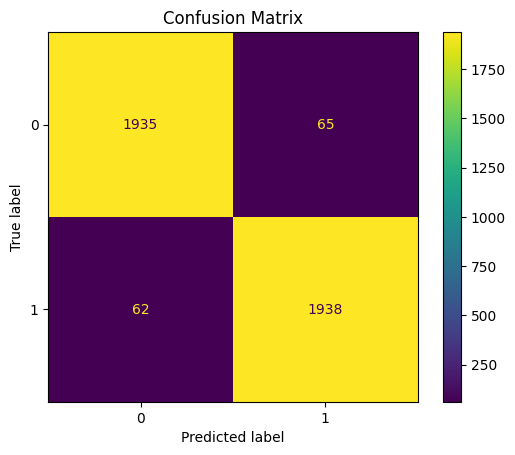

In [99]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')
plt.title('Confusion Matrix')
plt.show()


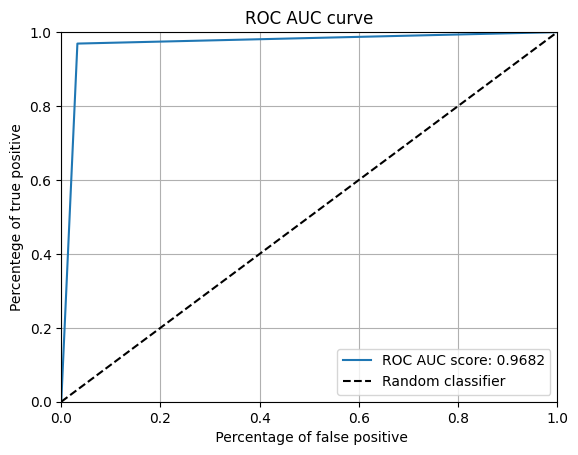

In [100]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred)

plt.plot(fpr, tpr, label=f'ROC AUC score: {test_auc:.4f}')
plt.plot([0,1], [0, 1], 'k--', label='Random classifier')
plt.xlabel(' Percentage of false positive')
plt.ylabel('Percentege of true positive')
plt.axis([0, 1, 0, 1])
plt.title('ROC AUC curve')
plt.legend()
plt.grid()
plt.show()

In [106]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

ml_client = MLClient.from_config(credential=DefaultAzureCredential())
ws = ml_client.workspaces.get(name=ml_client.workspace_name)

mlflow.set_tracking_uri(ws.mlflow_tracking_uri)
experiment_name = 'ACMG_Research_optuna_v3'
mlflow.set_experiment(experiment_name)

mlflow_callback = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name='roc_auc',
    create_experiment=False
)

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),  
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss', 
        'random_state': 42,
        'n_jobs': 1,
    }
    model = XGBClassifier(**params)
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(model_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
    return np.mean(scores)

study_name = 'xgb-acmg-tuning-research'

study = optuna.create_study(
    study_name=study_name,
    direction='maximize'
)

study.optimize(objective, n_trials=50, n_jobs=1, callbacks=[mlflow_callback])

print(f"ROC AUC best score: {study.best_value:.4f}")

best_params = study.best_params
best_params['n_jobs'] = -1

with mlflow.start_run(run_name='Best_XGB_Research_Optuna_Final') as run:
    mlflow.log_params(best_params)
    mlflow.log_metric('final_roc_auc', study.best_value)
    final_model = XGBClassifier(**best_params)
    final_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('final_model', final_model)
    ])
    final_pipeline.fit(X_train, y_train)
    temp_model_dir = "temp_final_model"
    if os.path.exists(temp_model_dir):
        shutil.rmtree(temp_model_dir)
        
    mlflow.sklearn.save_model(final_pipeline, path=temp_model_dir)    
    mlflow.log_artifacts(temp_model_dir, artifact_path="model")
    shutil.rmtree(temp_model_dir)

In [107]:
model_name = "acmg-xgboost-research"
model_version = '1'
model_uri = f'models:/{model_name}/{model_version}'
loaded_model = mlflow.sklearn.load_model(model_uri)

y_pred_proba = loaded_model.predict_proba(X_test)[:, 1]
val_auc = roc_auc_score(y_test, y_pred_proba)
print(f'AUC score on test data: {val_auc}')

AUC score on test data: 0.992589625


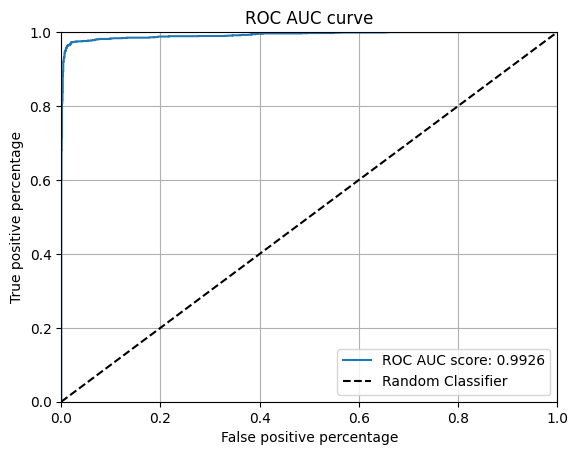

In [108]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f'ROC AUC score: {val_auc:.4f}')
plt.plot([0,1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False positive percentage')
plt.ylabel('True positive percentage')
plt.axis([0, 1, 0, 1])
plt.title('ROC AUC curve')
plt.legend()
plt.grid()
plt.show()

### 📊 ROC AUC Analysis
**Conclusion:** The model achieves an **AUC of 0.993**, indicating exceptional separability between pathogenic and benign classes.
* The curve's steep ascent shows a high True Positive Rate (Recall) with minimal False Positives.
* High performance is driven by strong predictors like `MC_IMPACT_SCORE` and the removal of noisy data (VUS), creating a distinct decision boundary.

In [109]:
y_test_pred = loaded_model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      2000
         1.0       0.98      0.97      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.98      0.97      0.97      4000
weighted avg       0.98      0.97      0.97      4000



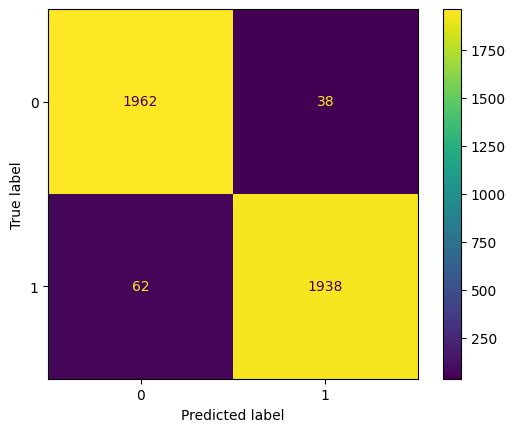

In [110]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')
plt.show()

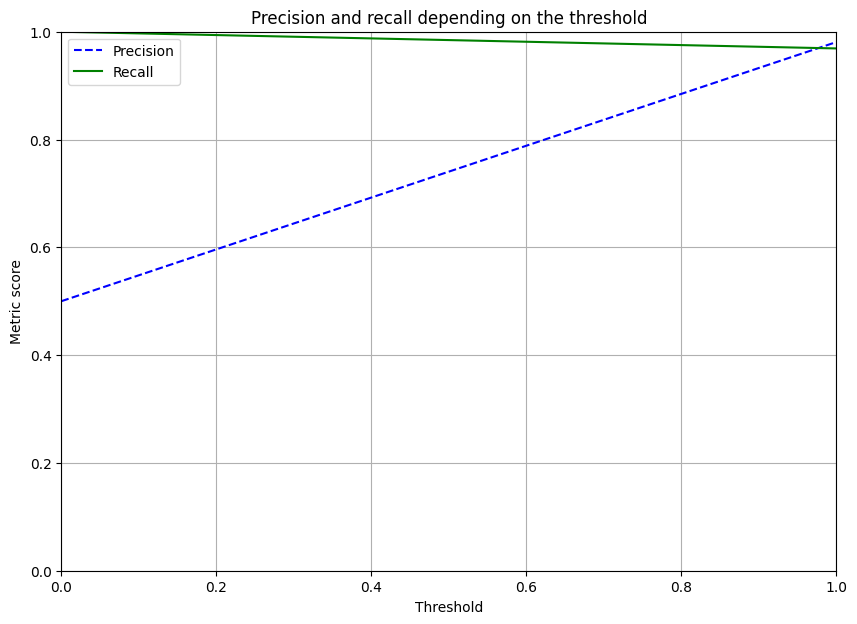

In [111]:
precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred)

plt.figure(figsize=(10, 7))
plt.plot(thresholds, precision[:-1], "b--", label="Precision") 
plt.plot(thresholds, recall[:-1], "g-", label="Recall")      
plt.xlabel("Threshold")
plt.ylabel("Metric score")
plt.title("Precision and recall depending on the threshold")
plt.grid(True)
plt.legend()
plt.axis([0, 1, 0, 1])
plt.show()

### 🎯 Precision-Recall vs. Threshold
**Conclusion:** The stability of the Recall curve (green) indicates the model is highly robust.
* Even at strict probability thresholds (e.g., >0.8), the model retains high sensitivity, which is critical in clinical diagnostics to avoid missing pathogenic variants (False Negatives).
* The linear behavior reflects the high polarization of the model's probability outputs (see Histogram below).

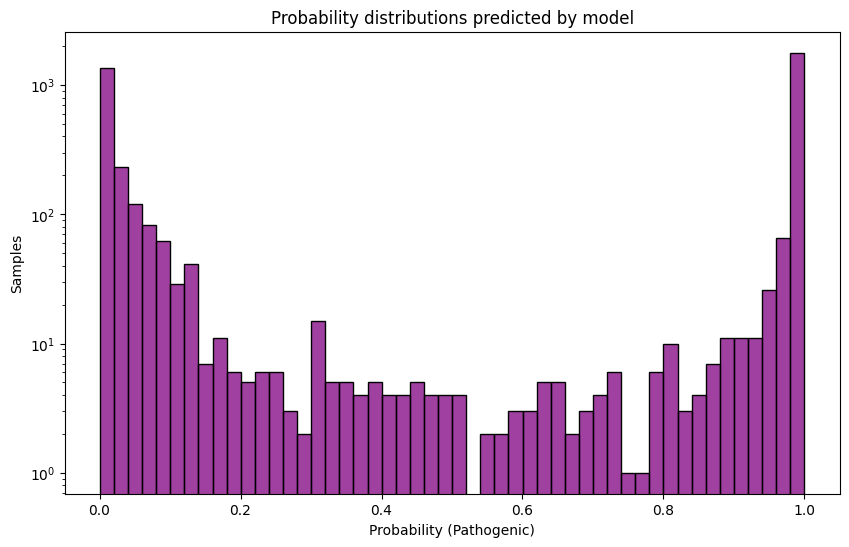

In [112]:
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_proba, bins=50, kde=False, color='purple')
plt.title("Probability distributions predicted by model")
plt.xlabel("Probability (Pathogenic)")
plt.ylabel("Samples")
plt.yscale('log') 
plt.show()

### 📉 Probability Distribution (Model Confidence)
**Conclusion:** The log-scale histogram reveals a highly confident model.
* **Bimodal Distribution:** Over 98% of predictions are clustered near 0.0 (Benign) or 1.0 (Pathogenic).
* **Edge Cases:** Only a negligible fraction of variants fall into the uncertainty zone (0.4–0.6). These likely represent "hard examples" with conflicting biological evidence (e.g., rare variants with benign computational scores).

In [113]:
print(loaded_model.named_steps.keys())

dict_keys(['preprocessor', 'final_model'])


PermutationExplainer explainer: 201it [00:21,  7.84it/s]                         


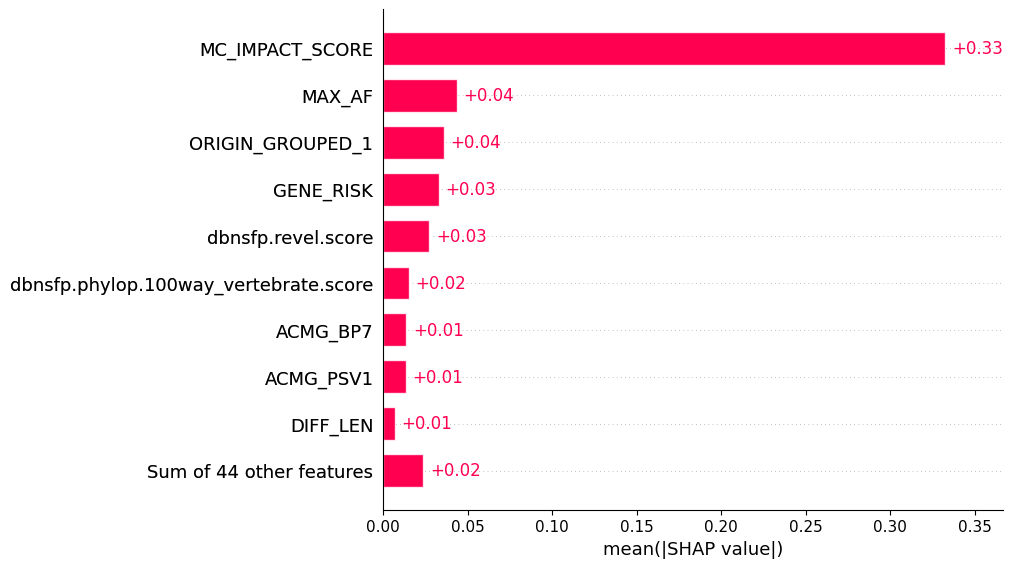

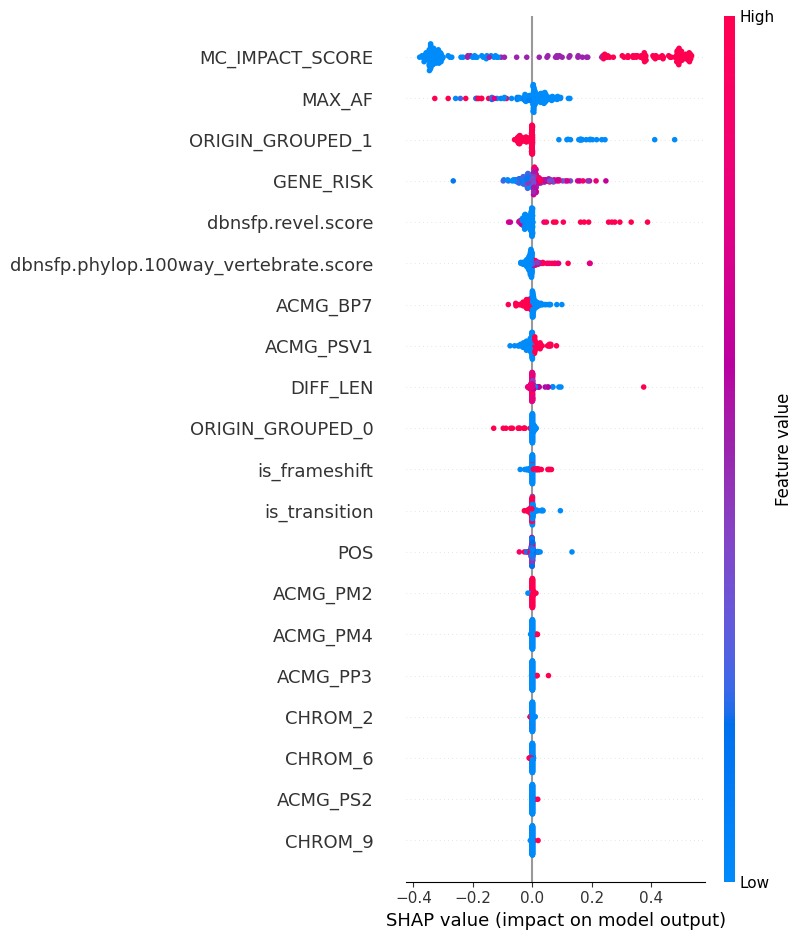

In [116]:
model_xgb = loaded_model.named_steps['final_model']
X_test_transformed = preprocessor.transform(X_test)
X_shap = X_test_transformed.iloc[:200] 

explainer = shap.Explainer(model_xgb.predict, X_shap)
shap_values = explainer(X_shap)


shap.plots.bar(shap_values)
shap.summary_plot(shap_values, X_shap)

In [123]:
preprocessor = final_pipeline.named_steps['preprocessor']
X_train_temp = preprocessor.transform(X_train)
X_test_temp = preprocessor.transform(X_test)

X_train_no_mc = X_train_temp.drop(columns=['MC_IMPACT_SCORE'], errors='ignore')
X_test_no_mc = X_test_temp.drop(columns=['MC_IMPACT_SCORE'], errors='ignore')

model = XGBClassifier(**best_params)
model.fit(X_train_no_mc, y_train)

auc_no_mc = roc_auc_score(y_test, model.predict_proba(X_test_no_mc)[:, 1])
print(f'ROC AUC score without MC_IMPACT_SCORE column: {auc_no_mc:.4f}')

ROC AUC score without MC_IMPACT_SCORE column: 0.9926


<Figure size 1000x700 with 0 Axes>

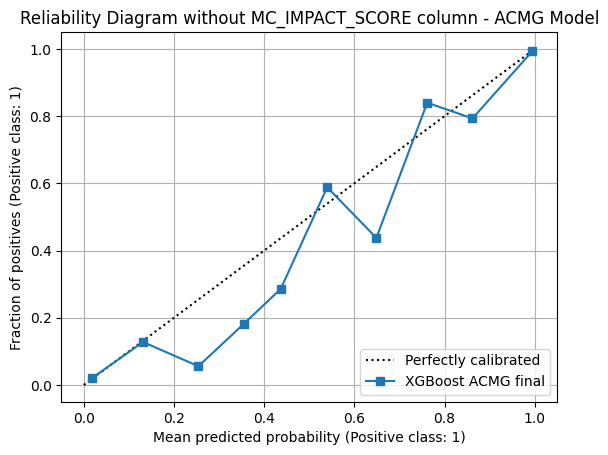

In [131]:
plt.figure(figsize=(10, 7))
disp = CalibrationDisplay.from_estimator(
    model,
    X_test_no_mc,
    y_test,
    n_bins=10,
    name='XGBoost ACMG final'
)

plt.title('Reliability Diagram without MC_IMPACT_SCORE column - ACMG Model')
plt.grid(True)
plt.show()

<Figure size 1000x700 with 0 Axes>

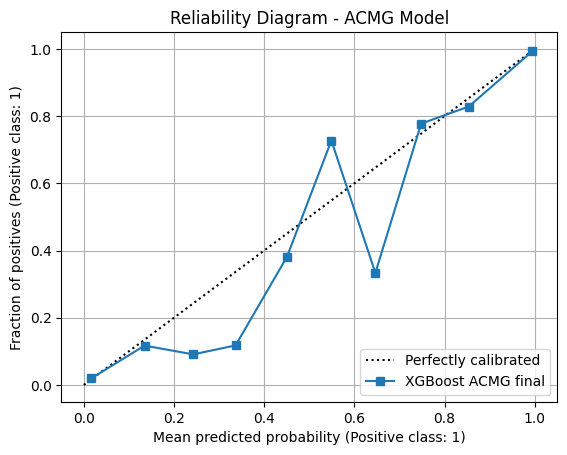

In [129]:
plt.figure(figsize=(10, 7))
disp = CalibrationDisplay.from_estimator(
    final_pipeline,
    X_test,
    y_test,
    n_bins=10,
    name='XGBoost ACMG final'
)

plt.title('Reliability Diagram - ACMG Model')
plt.grid(True)
plt.show()

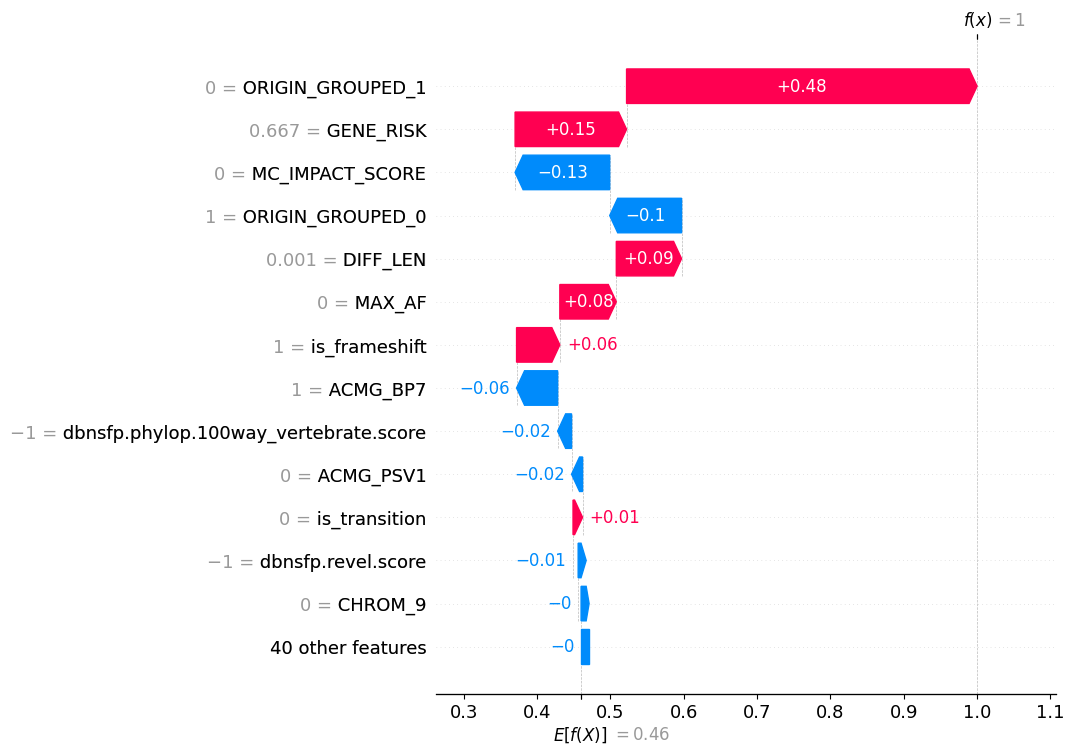

In [132]:
idx = 0 
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[idx], max_display=14, show=True)

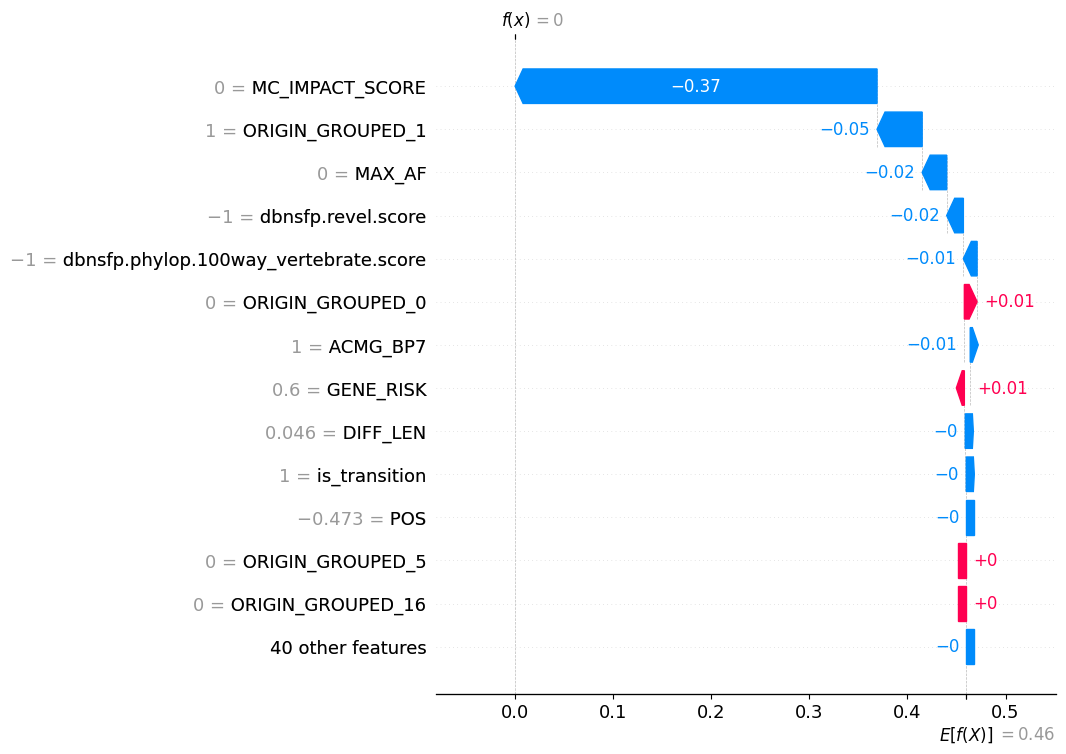

In [133]:
idx = 1
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[idx], max_display=14, show=True)

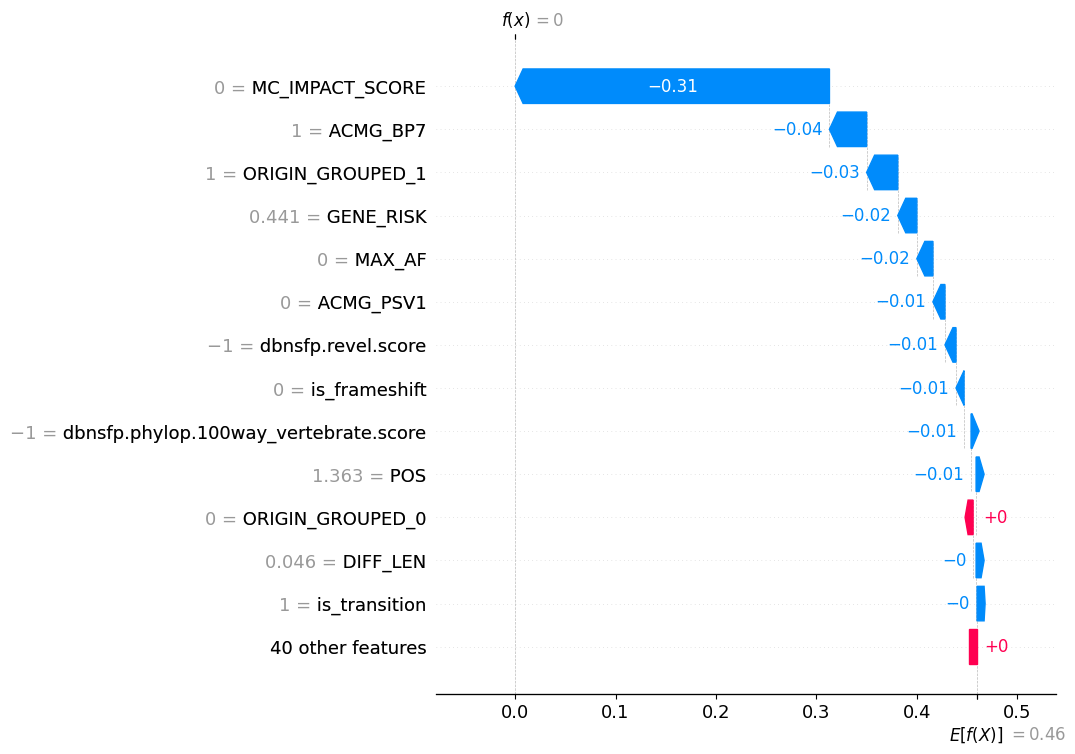

In [134]:
idx = 2
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[idx], max_display=14, show=True)

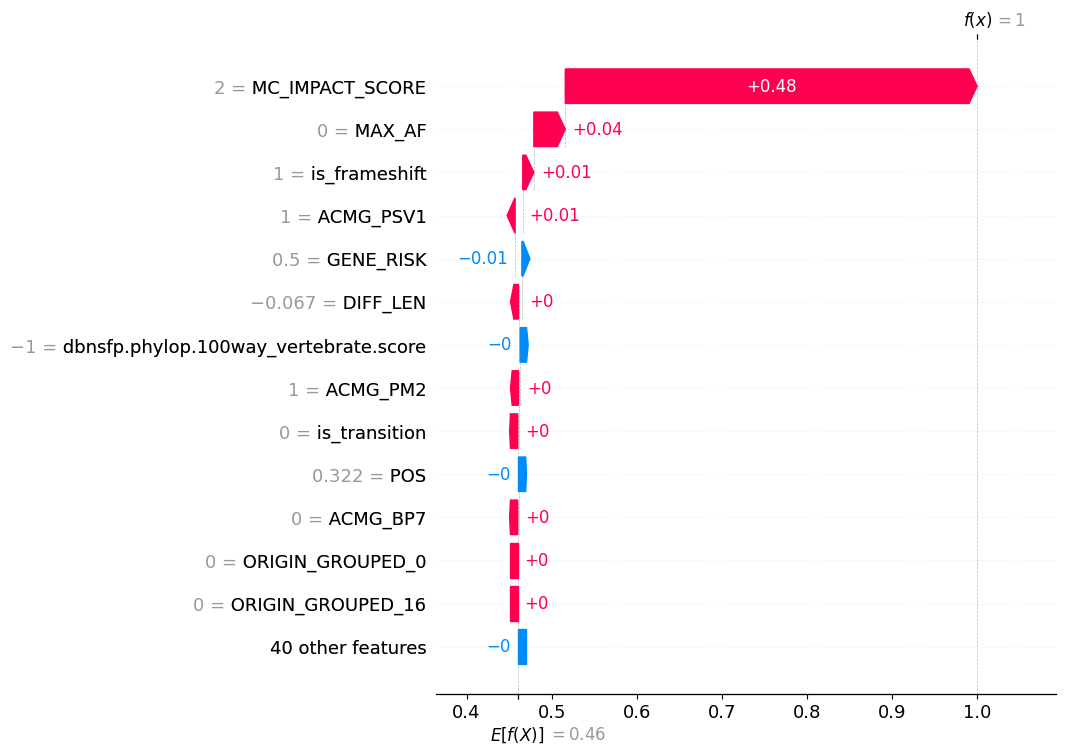

In [136]:
idx = 10
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[idx], max_display=14, show=True)